# Roman 72-Day Persistence Study



In [1]:
import argparse
import asdf
import warnings
import copy
from datetime import datetime, timedelta
import gc
import glob
import json
import logging
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import os
from pathlib import Path
import pandas as pd
import time
from typing import Dict, List, Tuple, Optional

import astropy
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import SigmaClip, sigma_clipped_stats
from astropy.table import Table
from astropy.visualization import simple_norm

import crds
import galsim
import romanisim
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.wcs import get_wcs
import romancal
from romancal.pipeline import ExposurePipeline
import roman_datamodels as rdm
from roman_datamodels.dqflags import pixel as dqflags

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats

import os
from matplotlib import gridspec


logging.getLogger().setLevel(logging.WARNING)


# Suppress expected ASDF warning when saving NaN values (saturated pixel replacement)
warnings.filterwarnings('ignore', message='invalid value encountered in cast', category=RuntimeWarning)

print(" All imports loaded")


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
 All imports loaded


#### Step 1: Set Variables

In [2]:
#Define star magnitude for catalog creation
MAG = 20

USE_SATURATION_REMOVAL = True  # Should match Cell 4 setting


RA, DEC = 79.922971, 30.034266


# Observation parameters
OBSERVATION_PERIOD_DAYS = 0.9
CADENCE_MINUTES = 12
CADENCE_SECONDS = CADENCE_MINUTES * 60  # 720 seconds
TOTAL_TIME_SECONDS = OBSERVATION_PERIOD_DAYS * 24 * 3600
N_EXPOSURES = int(TOTAL_TIME_SECONDS / CADENCE_SECONDS)  # 8,640 exposures

# Simulation parameters
SCA = 1
FILTER = 'F146'
FIELD_CENTER = [80, 30]  # RA, Dec in degrees
MA_TABLE = 1002
SEED = 42
BASE_TIME = '2026-10-15T00:00:00'

# Ensemble pixel configuration
N_ENSEMBLE_PIXELS = 1600  # 40×40 section for professor's analysis
ENSEMBLE_MIN_RADIUS = 00  # Closer to star (10-20 px range)
ENSEMBLE_MAX_RADIUS = 30  # 60×60 region

# Directories
MAGNITUDE_FOLDER = f'star_mag_{MAG:.2f}'
CATALOG_FILE_NAME = f'{MAGNITUDE_FOLDER}/star{MAG:.2f}.ecsv'
RESULTS_DIR = f'./{MAGNITUDE_FOLDER}/analysis_results'
TEMP_L1_DIR = f'./{MAGNITUDE_FOLDER}/temp_l1_processing'
CHECKPOINT_FILE = f'./{MAGNITUDE_FOLDER}/checkpoint.json'
MULTI_PIXEL_CSV = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL else 'multi_pixel_resultant1_sat.csv')


#### Step 2: Create Catalog

In [4]:
# Create catalog with single start at center:
#Center: RA=79.922971, Dec=30.034266
# we're using the center of the sensorfor the star location

# Create catalog files for stars with magnitudes from 10 to 15

cat = Table()
cat['ra'] =  [79.922971]
cat['dec'] = [30.034266]
cat['type'] = ['PSF']
cat['n'] = [-1]
cat['half_light_radius'] = [-1]
cat['pa'] = [-1]
cat['ba'] = [-1]
cat['F146'] = [10**(-0.4*MAG)]  # H=12 in maggies

# Create directory if it doesn't exist
os.makedirs(f'star_mag_{MAG:.2f}', exist_ok=True)

cat.write(f'star_mag_{MAG:.2f}/star{MAG:.2f}.ecsv', format='ascii.ecsv', overwrite=True)

    
''' generates files with catalog in this format

ra dec type n half_light_radius pa ba F146
79.922971 30.034266 PSF -1 -1 -1 -1 0.0001

'''

print(10.**(-1./2.5*MAG))
print(f' Catalog: star{MAG:.2f}.ecsv')

1e-08
 Catalog: star20.00.ecsv


## Global Configuration

In [5]:
parameters.read_pattern[1002]= [
      [1],                    # JCZ added the reference resultant
      [2],                    # Resultant 1: 1 read
      [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],  # Resultant 3: 13 reads
      [18, 19, 20, 21],       # Resultant 4: 4 reads
      [22]                    # Resultant 5: 1 read
]

RESULTANT_TIMES = {
    0: 3.16247,   # JCZ changed these
    1: 6.32494,
    2: 12.64988,
    3: 53.762,
    4: 66.41188,
    5: 69.57435
}



# PERSISTENCE MODELING: Each exposure uses the previous L1 file to model
# detector persistence effects. The pipeline automatically passes the previous
# L1 file to romanisim for accurate persistence simulation across the time series.

# Output CSV files
L1_METRICS_CSV = os.path.join(RESULTS_DIR, f'l1_metrics_Mag_{MAG:.2f}.csv')
PHOTOMETRY_CSV = os.path.join(RESULTS_DIR, f'Photometry_Mag_{MAG:.2f}.csv')
PERSISTENCE_CSV = os.path.join(RESULTS_DIR, f'persistence_Mag_{MAG:.2f}.csv')
MULTI_PIXEL_CSV = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL else 'multi_pixel_resultant1_sat.csv')

PIXELS_TO_TRACK = []  # Will be populated dynamically



# Source positions for photometry
# source_positions will be set dynamically after auto-detection
source_positions = []  # Will be populated during L2 processing

# ============================================================================
# PHOTOMETRIC CALIBRATION CONSTANTS
# ============================================================================

# Roman WFI F146 filter parameters
PIXEL_SCALE = 0.11  # arcsec/pixel
PHOTFLAM = 3.0151335e-20  # erg/cm^2/Angstrom/electron for F146
PHOTPLAM = 14539.0  # Pivot wavelength in Angstroms for F146
ZERO_POINT_AB = 28.08  # AB magnitude zero point for F146

# Conversion factor: DN to Jy
COUNTS_TO_JY = PIXEL_SCALE**2 * PHOTFLAM * PHOTPLAM / 3.34e4

source_y, source_x = 2000, 2000  # Fixed position
peak_value = 55000
# Calibration constants
RESULTANT0_TIME = 3.16247
photmjsr = 0.240393
pixel_area = 2.8083e-13
photfnu = photmjsr * 1e6 * pixel_area

print(" Photometric constants loaded")


print(" Global configuration loaded")

 Photometric constants loaded
 Global configuration loaded


## Step 3: Load Functions

In [6]:
def get_asdf_file(file_path):
    """Open ASDF file."""
    return asdf.open(file_path, 'rb')

def get_roman_dm_file(file_path):
    """Open file with roman_datamodels."""
    with asdf.open(file_path, 'rb') as fb:
        f = rdm.open(fb).copy()
    return f

def get_metadata(file_path):
    """Extract metadata from file."""
    f = get_roman_dm_file(file_path)
    return f.meta

def get_data(file_path):
    """Extract data array from file."""
    f = get_roman_dm_file(file_path)
    return f.data

def get_data_quality_section(file_path):
    """Extract DQ array from file."""
    f = get_roman_dm_file(file_path)
    return f.dq

def get_list_of_asdf_files(directory):
    """Get list of ASDF files in directory, sorted by creation time."""
    dir_path = Path(directory)
    if not dir_path.is_dir():
        raise NotADirectoryError(f"{directory} is not a valid directory.")
    
    asdf_files = list(dir_path.glob('*.asdf'))
    asdf_files.sort(key=lambda x: os.path.getctime(x))
    return asdf_files

def plot_resultants_for_pixel(file, pixel_x, pixel_y):
    """Plot up-the-ramp samples for a specific pixel."""
    plt.figure(figsize=(6, 6), layout='tight')
    plt.title(f'Up-the-ramp samples for pixel {pixel_x}, {pixel_y}')
    plt.plot(file['data'][:, pixel_x, pixel_y])
    plt.xlabel('Resultant number', fontsize=16)
    plt.ylabel('Pixel value [DN]', fontsize=16)
    plt.show()

def get_saturated_pixel_count(file_path):
    """Get number of saturated pixels from DQ flags."""
    f = get_asdf_file(file_path)
    # L1 files do not have data quality flags
    if f['romanisim']['level'] == 1:
        return None
    bit = 1  # Saturation bit
    definition = str(dqflags(bit)).split('.')[1]
    n_pix = np.sum(np.bool_(f['dq'].flatten() & (1 << bit)))
    print(f'Bit value {bit} corresponds to {definition}')
    print(f'Number of {definition} pixels: {n_pix:,} ({n_pix / f["dq"].size:.2%})')
    return n_pix

def get_exposure_metadata(file_path):
    """Extract exposure metadata."""
    f = get_roman_dm_file(file_path)
    return f.meta.exposure

def get_exposure_start_time(file_path):
    """Get exposure start time."""
    f = get_roman_dm_file(file_path)
    start_time = Time(f.meta.exposure.start_time, format='isot', scale='utc')
    return start_time

def get_exposure_end_time(file_path):
    """Get exposure end time."""
    f = get_roman_dm_file(file_path)
    end_time = Time(f.meta.exposure.end_time, format='isot', scale='utc')
    return end_time

def get_effective_exposure_time(file_path):
    """Get effective exposure time."""
    f = get_roman_dm_file(file_path)
    effective_exposure_time = f.meta.exposure.effective_exposure_time * u.s
    return effective_exposure_time

def get_exposure_time(file_path):
    """Get exposure time."""
    f = get_roman_dm_file(file_path)
    exposure_time = f.meta.exposure.exposure_time * u.s
    return exposure_time

def get_frame_time(file_path):
    """Get frame time."""
    f = get_roman_dm_file(file_path)
    frame_time = f.meta.exposure.frame_time * u.s
    return frame_time

def get_number_of_resultants(file_path):
    """Get number of resultants."""
    f = get_roman_dm_file(file_path)
    return f.meta.exposure.nresultants

def get_dq_saturated_pixels(file_path):
    """Get DQ saturated pixels."""
    f = get_roman_dm_file(file_path)
    return f.pixels

def get_catalog(file_name):
    """Load catalog from file."""
    catalog = Table.read(file_name, format="ascii.ecsv")
    return catalog

def galactic_to_equatorial(l, b):
    """
    Convert galactic coordinates to equatorial (RA, Dec).
    
    Parameters:
    -----------
    l : float or array
        Galactic longitude in degrees
    b : float or array
        Galactic latitude in degrees
    
    Returns:
    --------
    ra, dec : float or array
        Right Ascension and Declination in degrees
    """
    l = np.asarray(l, dtype=float)
    b = np.asarray(b, dtype=float)
    
    valid_mask = np.isfinite(l) & np.isfinite(b)
    
    if not np.any(valid_mask):
        raise ValueError("No valid galactic coordinates found")
    
    coord = SkyCoord(l * u.degree, b * u.degree, frame='galactic')
    equatorial = coord.icrs
    
    return equatorial.ra.degree, equatorial.dec.degree

#### Ensemble Selection

In [7]:
def select_ensemble_pixels(star_y, star_x, max_radius=20, image_size=4088, **kwargs):
    """
    Return all pixels within max_radius of the star position.
    Returns list of pixel dicts with 'name', 'y', 'x', 'description'
    """
    pixels = []
    r2 = max_radius**2
    idx = 0

    # Define bounding box around star
    y_min = max(0, int(star_y - max_radius))
    y_max = min(image_size, int(star_y + max_radius + 1))
    x_min = max(0, int(star_x - max_radius))
    x_max = min(image_size, int(star_x + max_radius + 1))
    print(y_min)
    print(y_max)
    print(x_min)
    print(x_max)
    for y in range(y_min, y_max):
        for x in range(x_min, x_max):
            dy = y - star_y
            dx = x - star_x

            #if dy*dy + dx*dx <= r2: # JCZ take the whole square not a circle
            if True:
                distance = np.sqrt(dy*dy + dx*dx)
                pixels.append({
                    'name': f'psf_wing_{idx:06d}',
                    'y': y,
                    'x': x,
                    'description': f'{distance:.1f}px from center'
                })
                idx += 1

    return pixels

####  MULTI-RESULTANT CSV FILES

In [8]:
def get_multi_pixel_csv_files(results_dir, use_saturation_removal=True):
    """Get CSV file paths for all resultants."""
    mode = "unsat" if use_saturation_removal else "sat"
    csv_files = {}
    
    for resultant in range(len(RESULTANT_TIMES)): 
        filename = f'multi_pixel_resultant{resultant}_{mode}.csv'
        csv_files[resultant] = os.path.join(results_dir, filename)
    
    return csv_files

MULTI_PIXEL_CSV_FILES = get_multi_pixel_csv_files(RESULTS_DIR, USE_SATURATION_REMOVAL)
SINGLE_PIXEL_CSV = os.path.join(RESULTS_DIR, 'single_pixel_resultant1.csv')



#### INTERMEDIATE DATA EXTRACTION CONFIGURATION


In [9]:
# Enable/disable extraction of intermediate file data
EXTRACT_JUMPS = False         # DISABLED for speed
EXTRACT_WCS = False           # DISABLED for speed
EXTRACT_RAMP_QUALITY = False  # Ramp fit quality (Optional)
EXTRACT_DQ_FLAGS = False      # DQ flags summary (Optional)

print(" Intermediate data extraction configured")
print(f"  Jump detection: {EXTRACT_JUMPS}")
print(f"  WCS astrometry: {EXTRACT_WCS}")
print(f"  Ramp quality: {EXTRACT_RAMP_QUALITY}")
print(f"  DQ flags: {EXTRACT_DQ_FLAGS}")


 Intermediate data extraction configured
  Jump detection: False
  WCS astrometry: False
  Ramp quality: False
  DQ flags: False


#### ROMAN L1 GENERATION FUNCTION

In [10]:
def run_romanisim_simulationapi(
    catalog_file,
    filter_name='F146',
    sca=1,
    level=1,
    exposure_params=None,
    pointing=(270.0, -30.0),
    date='2026-06-15T12:00:00',
    output_directory='./L1_simulation_files',
    output_suffix="",
    previous_file=None,
    usecrds=True
):
    """Generate Roman L1 simulation file using romanisim."""
    
    detector = f'WFI{sca:02d}'
    output_filename = f"{output_directory}/roman_sim_{filter_name}_{detector}_L{level}{output_suffix}.asdf"
    
    # Get parameters from exposure_params dict
    ma_table_number = exposure_params.get('ma_table_number', 1002) if exposure_params else 1002
    seed = exposure_params.get('seed', 7) if exposure_params else 7
    
    # Set up argument parser (no add_args - not needed)
    parser = argparse.ArgumentParser()
    parser.set_defaults(
        usecrds=usecrds, 
        stpsf=True, 
        level=level, 
        filename=output_filename, 
        drop_extra_dq=True, 
        sca=sca, 
        bandpass=filter_name, 
        pretend_spectral=None
    )
    
    args = parser.parse_args([])
    
    # Set reference files to None for CRDS
    for k in parameters.reference_data:
        parameters.reference_data[k] = None
    
    # Set Galsim RNG object
    rng = galsim.UniformDeviate(seed)
    
    # Set persistence information
    if previous_file and os.path.exists(previous_file):
        persist = persistence.Persistence.read(previous_file)
    else:
        persist = persistence.Persistence()
    
    # Set metadata using romanisim's helper
    metadata = ris.set_metadata(
        date=date, 
        bandpass=filter_name, 
        sca=sca, 
        #ma_table_number=ma_table_number, # JCZ adding this directly because otherwise it is not working by just giving ma_table_number
        usecrds=usecrds
    )
    
    # Update the WCS info
    wcs.fill_in_parameters(
        metadata, 
        SkyCoord(pointing[0], pointing[1], unit='deg', frame='icrs'), 
        boresight=False, 
        pa_aper=0.0
    )
    
    # Load catalog
    cat = astropy.table.Table.read(catalog_file)
    # JCZ
    # adding in the read pattern directly
    metadata['exposure']['read_pattern'] =[
          [1],                    # JCZ added the reference resultant
      [2],                    # Resultant 1: 1 read
      [3, 4],                 # Resultant 2: 2 reads 
      [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],  # Resultant 3: 13 reads
      [18, 19, 20, 21],       # Resultant 4: 4 reads
      [22]                    # Resultant 5: 1 read
]
    # Run the simulation
    ris.simulate_image_file(args, metadata, cat, rng, persist)
    
    return output_filename

print(" L1 generation function loaded")

 L1 generation function loaded


#### ROMAN L1 RESULTANT ANALYZER CLASS

In [11]:
class RomanL1ResultantAnalyzer:
    """
    Analyzer for individual resultants in Roman L1 files with proper MA table handling.
    Full implementation from Master notebook.
    """
    
    def __init__(self, l1_file_path: str):
        """
        Initialize with L1 file path.
        
        Parameters:
        -----------
        l1_file_path : str
            Path to L1 ASDF file
        """
        self.file_path = l1_file_path
        self.model = None
        
        # Data containers
        self.ramp_data = None  # (resultants, y, x)
        self.ref_pixels = None
        self.resultants = {}
        self.exposure_metadata = {}
        
        # MA table and timing information
        self.ma_table_info = {}
        self.read_pattern = []
        self.resultant_times = None
        self.frame_times = None
        
        # Processed data
        self.slopes = None
        self.slope_errors = None
        self.corrected_ramp = None
        self.saturation_mask = None
        
        # Read noise per detector (actual Roman WFI values)
        # These are the measured read noise values for each WFI detector
        self.sca_read_noise = {
            'WFI01': 17.49, 'WFI02': 14.20, 'WFI03': 14.70, 'WFI04': 15.76,
            'WFI05': 13.64, 'WFI06': 13.65, 'WFI07': 13.21, 'WFI08': 12.49,
            'WFI09': 12.39, 'WFI10': 15.75, 'WFI11': 13.94, 'WFI12': 13.73,
            'WFI13': 16.17, 'WFI14': 13.46, 'WFI15': 13.46, 'WFI16': 13.49,
            'WFI17': 12.64, 'WFI18': 12.42,
        }
        
        # Exposure time from MA table
        self.exposure_time = None
    
    def load_l1_file(self):
        """Load the L1 file and extract comprehensive metadata."""
        print(f"Loading L1 file: {self.file_path}")
        
        self.model = rdm.open(str(self.file_path))
        self.ramp_data = self.model.data
        
        # Extract detailed exposure metadata
        meta = self.model.meta
        exposure = meta.exposure
        
        self.exposure_metadata = {
            'type': exposure.type,
            'start_time': exposure.start_time,
            'mid_time': exposure.mid_time,
            'end_time': exposure.end_time,
            'nresultants': exposure.nresultants,
            'frame_time': exposure.frame_time,
            'exposure_time': exposure.exposure_time,
            'effective_exposure_time': exposure.effective_exposure_time,
            'ma_table_name': exposure.ma_table_name,
            'ma_table_number': exposure.ma_table_number,
            'truncated': exposure.truncated,
            'data_problem': exposure.data_problem,
            'detector': meta.instrument.detector,
            'optical_element': meta.instrument.optical_element,
            'read_noise': self.sca_read_noise.get(meta.instrument.detector, 5.0)
        }
        
        # Store exposure time
        self.exposure_time = exposure.exposure_time
        
        # Extract the actual read pattern (MA table structure)
        self.read_pattern = exposure.read_pattern
        

        print(f"Found MA table read pattern with {len(self.read_pattern)} resultants")
        
        # Process the MA table information
        self._process_ma_table()
        
        print(f"Loaded ramp data: {self.ramp_data.shape}")
        print(f"MA table {self.exposure_metadata.get('ma_table_number', '?')}: "
              f"{len(self.read_pattern)} resultants")
    
    def _process_ma_table(self):
        """Process the MA table read pattern to understand timing."""
        frame_time = self.exposure_metadata['frame_time']
        
        # Calculate timing for each resultant based on the read pattern
        self.resultant_times = []
        self.frame_times = []
        
        for i, read_group in enumerate(self.read_pattern):
            # Each read_group is a list of frame numbers
            if len(read_group) > 0:
                last_frame_number = max(read_group)
                resultant_time = last_frame_number * frame_time
                
                self.resultant_times.append(resultant_time)
                self.frame_times.append(read_group)
                
                print(f"  Resultant {i}: frames {read_group}, time = {resultant_time:.2f}s")
        
        self.resultant_times = np.array(self.resultant_times)
        
        # Store MA table analysis
        self.ma_table_info = {
            'total_frames': max([max(group) for group in self.read_pattern if group]),
            'total_time': self.resultant_times[-1] if len(self.resultant_times) > 0 else 0,
            'resultant_count': len(self.read_pattern),
            'frame_time': frame_time
        }
        
        print(f"  MA table: {self.ma_table_info['total_frames']} frames, "
              f"{self.ma_table_info['total_time']:.2f}s total")

    def extract_all_resultants(self):
        """Extract individual resultant arrays with proper MA table context."""
        print("Extracting individual resultants with MA table context...")

        for i in range(self.exposure_metadata["nresultants"]):
            resultant_name = f"resultant_{i:02d}"
            self.resultants[resultant_name] = self.ramp_data[i, :, :].copy()
            
            # Get information about this resultant from MA table
            if i < len(self.read_pattern):
                read_group = self.read_pattern[i]
                n_frames_averaged = len(read_group) 
                resultant_time = self.resultant_times[i] if i < len(self.resultant_times) else 0
            else:
                n_frames_averaged = 1
                resultant_time = 0
            
            # Basic statistics
            valid_mask = np.isfinite(self.resultants[resultant_name])
            if np.any(valid_mask):
                mean_val = np.mean(self.resultants[resultant_name][valid_mask])
                median_val = np.median(self.resultants[resultant_name][valid_mask])
                print(f"  {resultant_name}: time={resultant_time:.2f}s, "
                           f"frames_avg={n_frames_averaged}, "
                           f"mean={mean_val:.1f} DN, median={median_val:.1f} DN")
        
        print(f"Extracted {len(self.resultants)} resultants")
        return self.resultants

    
    def casertano_weighted_fit(self, times, counts, read_noise=10.0):
        """
        Implement Casertano (2022) optimal weighting scheme.
        
        Adapts weighting based on signal-to-noise ratio:
        - Low S/N: Equal weighting (read noise dominated)
        - High S/N: Endpoints only (Poisson dominated)
        - Intermediate: Smooth transition
        """
        N = len(times)
        if N < 2:
            return 0.0, np.inf
        
        # Convert to float64 to prevent overflow
        counts = np.asarray(counts, dtype=np.float64)
        times = np.asarray(times, dtype=np.float64)
        
        # Calculate signal-to-noise ratio
        S_max = counts[-1] - counts[0]
        if S_max <= 0:
            S_max = np.abs(counts[-1] - counts[0]) + 1.0
        
        S = S_max / np.sqrt(read_noise**2 + S_max)
        
        # Calculate optimal weights based on S/N
        weights = self.calculate_casertano_weights(times, S, read_noise)
        
        # Apply weighted least squares
        W = weights
        t_bar = times - times[0]  # Relative times
        
        # Auxiliary sums (Casertano method)
        F0 = np.sum(W)
        F1 = np.sum(W * t_bar)
        F2 = np.sum(W * t_bar**2)
        
        D = F0 * F2 - F1**2
        if abs(D) < 1e-15:
            return 0.0, np.inf
        
        # Coefficients and slope calculation
        K = (F0 * t_bar - F1) / D
        slope = np.sum(K * counts)
        
        # Calculate uncertainty
        tau = times - times[0]
        V_S = np.sum(K**2 * tau) + np.sum([2 * K[i] * K[j] * t_bar[i] 
                                        for i in range(N) for j in range(i+1, N)])
        V_R = np.sum(K**2) * read_noise**2
        V_total = V_S * abs(slope) + V_R
        slope_error = np.sqrt(max(V_total, 0))
        
        return slope, slope_error
    
    def calculate_casertano_weights(self, times, S, read_noise):
        """
        Calculate optimal weights based on S/N ratio.
        
        Parameters:
        -----------
        S : float
            Signal-to-noise ratio
        
        Returns:
        --------
        weights : array
            Optimal weights for each resultant
        """
        N = len(times)
        
        # Low S/N: equal weighting (read noise dominated)
        if S < 0.1:
            return np.ones(N)
        
        # High S/N: first and last samples only (Poisson dominated)
        elif S > 10.0:
            weights = np.zeros(N)
            weights[0] = 1.0   # First
            weights[-1] = 1.0  # Last
            return weights
        
        # Intermediate S/N: smooth transition
        else:
            equal_weights = np.ones(N)
            endpoint_weights = np.zeros(N)
            endpoint_weights[0] = 1.0
            endpoint_weights[-1] = 1.0
            
            # Sigmoid transition parameter
            alpha = 1.0 / (1.0 + np.exp(-2 * (S - 2)))
            weights = (1 - alpha) * equal_weights + alpha * endpoint_weights
            
            return weights
    
    def reference_pixel_correction(self, method='median_subtract'):
        """Apply reference pixel correction using 4-pixel border."""
        # Convert to float64 for calculations
        self.corrected_ramp = self.ramp_data.astype(np.float64)
        
        if method == 'none':
            return
        
        for i in range(self.corrected_ramp.shape[0]):
            resultant = self.corrected_ramp[i, :, :]
            
            # Extract reference pixels from 4-pixel border
            ref_pixels = np.concatenate([
                resultant[:4, :].flatten(),      # Top 4 rows
                resultant[-4:, :].flatten(),     # Bottom 4 rows
                resultant[4:-4, :4].flatten(),   # Left 4 cols
                resultant[4:-4, -4:].flatten()   # Right 4 cols
            ])
            
            valid_ref = ref_pixels[np.isfinite(ref_pixels)]
            
            if len(valid_ref) > 0:
                if method == 'median_subtract':
                    correction = np.median(valid_ref)
                else:  # mean_subtract
                    correction = np.mean(valid_ref)
                
                # Apply correction to science region
                self.corrected_ramp[i, 4:-4, 4:-4] -= correction
    
    def fit_up_the_ramp_slopes(self, method='casertano', read_noise=10.0):
        """
        Fit slopes using Casertano optimal weighting.
        
        This is the Master notebook's full implementation.
        """
        data_to_fit = self.corrected_ramp if self.corrected_ramp is not None else self.ramp_data.astype(np.float64)
        ny, nx = data_to_fit.shape[1:]
        self.slopes = np.zeros((ny, nx))
        self.slope_errors = np.zeros((ny, nx))
        
        print(f"Fitting slopes with Casertano weighting (read_noise={read_noise:.1f} DN)...")
        
        for y in range(ny):
            for x in range(nx):
                times = self.resultant_times
                counts = data_to_fit[:, y, x]
                
                # Use Casertano optimal weighting
                slope, error = self.casertano_weighted_fit(times, counts, read_noise)
                
                self.slopes[y, x] = slope
                self.slope_errors[y, x] = error
        
        return self.slopes, self.slope_errors




#### Pixel Saturation

In [12]:
def get_saturated_pixels_and_neighbors(data, threshold): # Not used - no saturation replacement
    """
    Get saturated pixels and their 8 neighbors (FAST VECTORIZED - MASTER LOGIC).
    
    Matches Master notebook behavior:
    - Finds core saturated pixels
    - Adds 8 neighbors (3×3 box)
    - Prints core count like Master
    
    Parameters:
    -----------
    data : np.ndarray
        2D image data
    threshold : float
        Saturation threshold in DN
    
    Returns:
    --------
    saturated_pixels : list of tuples
        List of (y, x) coordinates including neighbors
    """
    from scipy import ndimage
    
    # Find core saturated pixels (vectorized - FAST!)
    saturated_mask = data >= threshold
    pixel_count = np.sum(saturated_mask)  # Core count
    
    if pixel_count == 0:
        print(f'  Core saturated pixels: 0')
        print(f'  Total with neighbors: 0')
        return []
    
    # Dilate to include 8 neighbors (vectorized - FAST!)
    structure = np.array([[1, 1, 1],
                         [1, 1, 1],
                         [1, 1, 1]], dtype=bool)
    
    dilated_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    # Convert mask to list of coordinates
    coords = np.where(dilated_mask)
    saturated_pixels = list(zip(coords[0], coords[1]))
    
    # Print like Master notebook
    print(f'  Core saturated pixels: {pixel_count}')
    print(f'  Total with neighbors: {len(saturated_pixels)}')
    
    return saturated_pixels

def replace_saturated_pixels(data, indices, replacement_value=np.nan): # Not used - no saturation replacement
    """
    Replace saturated pixels with specified value.
    
    From Master notebook - typically replaces with NaN for clean photometry.
    
    Parameters:
    -----------
    data : 2D array
        Data to modify
    indices : list of tuples
        Pixel coordinates to replace
    replacement_value : float
        Value to use (default: np.nan)
#    
    Returns:
    --------
    modified_data : 2D array
        Data with saturated pixels replaced
    """
    modified_data = data.copy()
    for index in indices:
        modified_data[index] = replacement_value
    
    return modified_data



def update_unsaturated_resultant(file_name, resultants_data): # Not used - no saturation replacement
    """
    Updates all resultants in the L1 file at once.
    
    From Master notebook - replaces saturated pixels in L1 BEFORE pipeline.
    
    Parameters:
    -----------
    file_name : str
        Path to the L1 ASDF file
    resultants_data : list of 2D arrays
        Modified resultant data, one for each resultant
    """
    with rdm.open(file_name) as model:
        new_model = model.copy()
        for i, data in enumerate(resultants_data):
            new_model.data[i, :, :] = data
        new_model.save(file_name.replace('.asdf', '_unsat.asdf'))
        return file_name.replace('.asdf', '_unsat.asdf')


In [13]:
def get_saturated_pixels_from_dq_with_neighbors(dq_array, saturation_threshold=65000):
    """
    Get saturated pixels from DQ flags OR threshold, with neighbors.
    
    Combines DQ flag method with threshold check for robustness.
    
    Parameters:
    -----------
    dq_array : 2D array
        DQ flags from L2
    saturation_threshold : float
        DN threshold for saturation (default 65000)
    
    Returns:
    --------
    coords : list of tuples
        Saturated pixel coordinates with neighbors
    n_core : int
        Core saturated pixels
    """
    from scipy import ndimage
    
    # Get saturated from DQ bit 1
    saturated_bit = 1
    saturated_mask = (dq_array & (1 << saturated_bit)) > 0
    
    n_core = np.sum(saturated_mask)
    
    # Dilate to include neighbors
    structure = np.ones((3, 3), dtype=bool)
    expanded_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    # Convert to coordinates
    coords = list(zip(*np.where(expanded_mask)))
    
    return coords, n_core


#### Single Pixel Variance withing One File

In [14]:
# ============================================================================
# ORIGINAL VARIANCE FUNCTIONS (across resultants within ONE file)
# ============================================================================

def calculate_single_pixel_variance(analyzer, pixel_y, pixel_x):
    """
    Calculate variance of a single pixel across all resultants.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
        The analyzer object containing the ramp data
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    
    Returns:
    --------
    variance : float
        Variance of the pixel values across all resultants
    pixel_data : dict
        Dictionary containing pixel values for each resultant
    """
    
    pixel_data = {}
    values = []
    
    # Extract value for each resultant
    for i in range(analyzer.ramp_data.shape[0]):
        value = analyzer.ramp_data[i, pixel_y, pixel_x]
        pixel_data[f'resultant_{i}'] = value
        if np.isfinite(value):  # Exclude NaN/inf values
            values.append(value)
    
    # Calculate variance
    variance = np.var(values) if len(values) > 0 else np.nan
    
    return variance, pixel_data


def plot_single_pixel_with_variance(analyzer, pixel_y, pixel_x, filename=None):
    """Plot DN value vs resultant for a single pixel and show variance."""
    
    variance, pixel_data = calculate_single_pixel_variance(analyzer, pixel_y, pixel_x)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    resultants = range(len(pixel_data))
    values_list = [pixel_data[f'resultant_{i}'] for i in resultants]
    
    # Plot 1: DN vs Resultant number
    ax1.plot(resultants, values_list, 'o-', markersize=8)
    ax1.set_xlabel('Resultant Number')
    ax1.set_ylabel('DN Value')
    ax1.set_title(f'Pixel [{pixel_y}, {pixel_x}] - DN vs Resultant\nVariance = {variance:.2f} DN²')
    ax1.grid(True, alpha=0.3)
    
    # Add mean line
    mean_val = np.nanmean(values_list)
    ax1.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean = {mean_val:.2f}')
    ax1.legend()
    
    # Plot 2: DN vs Time
    if analyzer.resultant_times is not None:
        ax2.plot(analyzer.resultant_times, values_list, 'o-', markersize=8)
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('DN Value')
        ax2.set_title(f'Pixel [{pixel_y}, {pixel_x}] - DN vs Time\nVariance = {variance:.2f} DN²')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean = {mean_val:.2f}')
        ax2.legend()
    
    # Add filename to suptitle if provided
    if filename:
        fig.suptitle(filename, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    return variance, pixel_data

def plot_multiple_pixels_variance(analyzer, pixel_coords, filename=None):
    """
    Plot DN values for multiple pixels and compare their variances.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
    pixel_coords : list of tuples
        List of (y, x) coordinates to plot
    filename : str, optional
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    variances = {}
    
    for pixel_y, pixel_x in pixel_coords:
        variance, pixel_data = calculate_single_pixel_variance(analyzer, pixel_y, pixel_x)
        resultants = range(len(pixel_data))
        values_list = [pixel_data[f'resultant_{i}'] for i in resultants]
        
        label = f'[{pixel_y}, {pixel_x}] (var={variance:.2f})'
        variances[(pixel_y, pixel_x)] = variance
        
        # Plot 1: DN vs Resultant
        ax1.plot(resultants, values_list, 'o-', label=label, markersize=6, alpha=0.7)
        
        # Plot 2: DN vs Time
        if analyzer.resultant_times is not None:
            ax2.plot(analyzer.resultant_times, values_list, 'o-', label=label, markersize=6, alpha=0.7)
    
    ax1.set_xlabel('Resultant Number')
    ax1.set_ylabel('DN Value')
    ax1.set_title('Multiple Pixels - DN vs Resultant')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    if analyzer.resultant_times is not None:
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('DN Value')
        ax2.set_title('Multiple Pixels - DN vs Time')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    if filename:
        fig.suptitle(filename, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    print("\nPixel Variances:")
    for coords, var in variances.items():
        print(f"  Pixel {coords}: {var:.2f} DN²")
    
    return variances

#### Source Detection

In [15]:
def detect_source_position(data, search_radius=500, central_region=True):
    """
    Automatically detect the brightest source in the image.
    
    Parameters:
    -----------
    data : np.ndarray
        2D image data
    search_radius : int
        Radius around center to search (if central_region=True)
    central_region : bool
        If True, only search central region (faster, assumes source near center)
    
    Returns:
    --------
    y, x : int, int
        Source position (row, column)
    peak_value : float
        Peak pixel value
    """
    
    if central_region:
        # Search only central region (faster)
        center_y, center_x = data.shape[0] // 2, data.shape[1] // 2
        y_start = max(0, center_y - search_radius)
        y_end = min(data.shape[0], center_y + search_radius)
        x_start = max(0, center_x - search_radius)
        x_end = min(data.shape[1], center_x + search_radius)
        
        search_region = data[y_start:y_end, x_start:x_end]
        
        # Find max in search region
        max_val = np.nanmax(search_region)
        local_max = np.where(search_region == max_val)
        
        # Convert back to full image coordinates
        source_y = y_start + local_max[0][0]
        source_x = x_start + local_max[1][0]
    else:
        # Search entire image
        max_val = np.nanmax(data)
        max_loc = np.where(data == max_val)
        source_y = max_loc[0][0]
        source_x = max_loc[1][0]
    
    return source_y, source_x, max_val

#### Pixel Tracking variance

In [16]:
# ============================================================================
# SINGLE PIXEL RESULTANT 1 VARIANCE TRACKING
# ============================================================================

def calculate_single_pixel_resultant1(analyzer, pixel_y, pixel_x):
    """
    Extract the value of a single pixel at RESULTANT 1 ONLY.
    
    Parameters:
    -----------
    analyzer : RomanL1ResultantAnalyzer
        The analyzer object containing the ramp data
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    
    Returns:
    --------
    resultant1_value : float
        Pixel value at resultant 1 (DN)
    """
    # Resultant 1 is at index 0
    resultant1_value = analyzer.ramp_data[0, pixel_y, pixel_x]
    
    return resultant1_value


def save_pixel_resultant1_to_csv(file_number, pixel_y, pixel_x, resultant1_value, 
                                  csv_filename, timestamp_sec=None):
    """
    Save single pixel resultant 1 data to CSV file.
    
    Parameters:
    -----------
    file_number : int
        Current file number being processed
    pixel_y : int
        Y coordinate of pixel
    pixel_x : int
        X coordinate of pixel
    resultant1_value : float
        Pixel value at resultant 1 (DN)
    csv_filename : str
        Path to CSV file
    timestamp_sec : float, optional
        Timestamp in seconds
    """
    # Create data dictionary
    data = {
        'file_number': file_number,
        'pixel_y': pixel_y,
        'pixel_x': pixel_x,
        'resultant_DN': resultant1_value,
        'timestamp_sec': timestamp_sec if timestamp_sec is not None else file_number
    }
    
    # Append to CSV
    df = pd.DataFrame([data])
    
    # Check if file exists to determine if we need header
    file_exists = os.path.exists(csv_filename)
    df.to_csv(csv_filename, mode='a', header=not file_exists, index=False)


def dn_to_jy(dn_values, photfnu):
    """Convert DN to Janskys."""
    return np.array(dn_values) * photfnu


def jy_to_magnitude(jy_values, ZERO_POINT_AB):
    """Convert Janskys to AB magnitudes."""
    jy_values = np.array(jy_values)
    with np.errstate(divide='ignore', invalid='ignore'):
        magnitudes = -2.5 * np.log10(jy_values) + ZERO_POINT_AB 
    return magnitudes


def plot_single_pixel_resultant1_variance(csv_filename, output_dir='./analysis_results',
                                          photfnu = None, mag_zero_point = None):
    """
    Plot single pixel resultant 1 variance in DN, Jy, and Magnitude.
    Run this AFTER your pipeline completes.
    """
    # Fall back to globals if not provided
    if output_dir is None:
        output_dir = RESULTS_DIR
    if photfnu is None:
        photfnu = photmjsr * 1e6 * PIXEL_AREA
    if mag_zero_point is None:
        mag_zero_point = ZERO_POINT_AB

    
    # Load data
    if not os.path.exists(csv_filename):
        print(f" ERROR: CSV file not found: {csv_filename}")
        return
    
    df = pd.read_csv(csv_filename)
    
    if df.empty:
        print(f" ERROR: CSV file is empty: {csv_filename}")
        return
    
    print(f" Loaded {len(df)} measurements from {csv_filename}")
    
    # Get pixel coordinates
    pixel_y = df['pixel_y'].iloc[0]
    pixel_x = df['pixel_x'].iloc[0]
    
    # Extract data
    file_numbers = df['file_number'].values
    dn_values = df['resultant_DN'].values
    
    # Convert to Jy and Magnitude
    jy_values = dn_to_jy(dn_values, photfnu)
    mag_values = jy_to_magnitude(jy_values, mag_zero_point)
    
    # Calculate statistics
    dn_mean = np.mean(dn_values)
    dn_std = np.std(dn_values)
    dn_var = np.var(dn_values)
    
    jy_mean = np.mean(jy_values)
    jy_std = np.std(jy_values)
    jy_var = np.var(jy_values)
    
    mag_mean = np.mean(mag_values[np.isfinite(mag_values)])
    mag_std = np.std(mag_values[np.isfinite(mag_values)])
    mag_var = np.var(mag_values[np.isfinite(mag_values)])
    
    # Create figure with 3 rows, 3 columns
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    fig.suptitle(f'Single Pixel Resultant 1 Variance Analysis\n' + 
                 f'Pixel ({pixel_y}, {pixel_x}) - {len(df)} Exposures',
                 fontsize=16, fontweight='bold', y=0.995)
    
    # ROW 1: DN
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(file_numbers, dn_values, 'b-', linewidth=1, alpha=0.6)
    ax1.plot(file_numbers, dn_values, 'bo', markersize=3, alpha=0.5)
    ax1.axhline(dn_mean, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {dn_mean:.2f} DN')
    ax1.fill_between(file_numbers, dn_mean - dn_std, dn_mean + dn_std,
                      alpha=0.2, color='red', label=f'±1σ = {dn_std:.2f} DN')
    ax1.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Resultant 1 Value (DN)', fontsize=11, fontweight='bold')
    ax1.set_title(f'DN Time Series - Variance = {dn_var:.2f} DN²', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(dn_values, bins=30, color='blue', alpha=0.7, edgecolor='black', 
             orientation='horizontal')
    ax2.axhline(dn_mean, color='red', linestyle='--', linewidth=2)
    ax2.set_ylabel('DN Value', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax2.set_title('DN Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # ROW 2: Flux
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax3.plot(file_numbers, jy_values, 'g-', linewidth=1, alpha=0.6)
    ax3.plot(file_numbers, jy_values, 'go', markersize=3, alpha=0.5)
    ax3.axhline(jy_mean, color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {jy_mean:.2e} Jy')
    ax3.fill_between(file_numbers, jy_mean - jy_std, jy_mean + jy_std,
                      alpha=0.2, color='red', label=f'±1σ = {jy_std:.2e} Jy')
    ax3.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Flux (Jy)', fontsize=11, fontweight='bold')
    ax3.set_title(f'Flux Time Series - Variance = {jy_var:.2e} Jy²', 
                  fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)
    ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.hist(jy_values, bins=30, color='green', alpha=0.7, edgecolor='black', 
             orientation='horizontal')
    ax4.axhline(jy_mean, color='red', linestyle='--', linewidth=2)
    ax4.set_ylabel('Flux (Jy)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax4.set_title('Flux Distribution', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # ROW 3: Magnitude
    ax5 = fig.add_subplot(gs[2, 0:2])
    finite_mask = np.isfinite(mag_values)
    ax5.plot(file_numbers[finite_mask], mag_values[finite_mask], 'r-', 
             linewidth=1, alpha=0.6)
    ax5.plot(file_numbers[finite_mask], mag_values[finite_mask], 'ro', 
             markersize=3, alpha=0.5)
    ax5.axhline(mag_mean, color='blue', linestyle='--', linewidth=2, 
                label=f'Mean = {mag_mean:.3f} mag')
    ax5.fill_between(file_numbers[finite_mask], mag_mean - mag_std, mag_mean + mag_std,
                      alpha=0.2, color='blue', label=f'±1σ = {mag_std:.3f} mag')
    ax5.set_xlabel('File Number', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
    ax5.set_title(f'Magnitude Time Series - Variance = {mag_var:.4f} mag²', 
                  fontsize=12, fontweight='bold')
    ax5.invert_yaxis()
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=9)
    
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.hist(mag_values[finite_mask], bins=30, color='red', alpha=0.7, 
             edgecolor='black', orientation='horizontal')
    ax6.axhline(mag_mean, color='blue', linestyle='--', linewidth=2)
    ax6.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title('Magnitude Distribution', fontsize=12, fontweight='bold')
    ax6.invert_yaxis()
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Save plot
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, 
                               f'single_pixel_resultant1_variance_y{pixel_y}_x{pixel_x}.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n Saved plot: {output_file}")
    
    output_file_pdf = output_file.replace('.png', '.pdf')
    plt.savefig(output_file_pdf, dpi=300, bbox_inches='tight')
    print(f" Saved PDF: {output_file_pdf}")
    
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("SINGLE PIXEL RESULTANT 1 VARIANCE SUMMARY")
    print("="*70)
    print(f"Pixel: ({pixel_y}, {pixel_x})")
    print(f"Number of exposures: {len(df)}")
    print(f"\nDN (Data Numbers):")
    print(f"  Mean:     {dn_mean:.3f} DN")
    print(f"  Std Dev:  {dn_std:.3f} DN")
    print(f"  Variance: {dn_var:.3f} DN²")
    print(f"  Range:    {np.min(dn_values):.3f} - {np.max(dn_values):.3f} DN")
    print(f"  CV:       {(dn_std/dn_mean*100):.2f}%")
    print(f"\nFlux (Janskys):")
    print(f"  Mean:     {jy_mean:.3e} Jy")
    print(f"  Std Dev:  {jy_std:.3e} Jy")
    print(f"  Variance: {jy_var:.3e} Jy²")
    print(f"  CV:       {(jy_std/jy_mean*100):.2f}%")
    print(f"\nMagnitude (AB):")
    print(f"  Mean:     {mag_mean:.4f} mag")
    print(f"  Std Dev:  {mag_std:.4f} mag")
    print(f"  Variance: {mag_var:.6f} mag²")
    print(f"  Range:    {np.min(mag_values[finite_mask]):.4f} - {np.max(mag_values[finite_mask]):.4f} mag")
    print("="*70)


#### PIPELINE HELPER FUNCTIONS

In [17]:
def save_checkpoint(file_number, total_processed):
    """Save checkpoint to resume later if interrupted."""
    checkpoint = {
        'last_completed': file_number,
        'total_processed': total_processed,
        'timestamp': time.time(),
    }
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(checkpoint, f)

def load_checkpoint():
    """Load checkpoint to resume processing."""
    try:
        with open(CHECKPOINT_FILE, 'r') as f:
            checkpoint = json.load(f)
        return checkpoint
    except FileNotFoundError:
        return {'last_completed': 0, 'total_processed': 0}

def cleanup_files(*filepaths):
    """Delete files to save space."""
    deleted = []
    for filepath in filepaths:
        if os.path.exists(filepath):
            os.remove(filepath)
            deleted.append(os.path.basename(filepath))
    return deleted

def estimate_completion(file_num, start_time, total_files):
    """Estimate remaining time."""
    elapsed = time.time() - start_time
    if file_num > 0:
        rate = file_num / elapsed
        remaining_files = total_files - file_num
        remaining_seconds = remaining_files / rate
        
        return {
            'elapsed_hours': elapsed / 3600,
            'remaining_hours': remaining_seconds / 3600,
            'remaining_days': remaining_seconds / 86400,
            'percent_complete': (file_num / total_files) * 100
        }
    return None


def cleanup_all_pipeline_files(base_filename, temp_dir):
    """
    Delete ALL .asdf files in temp directory.
    More aggressive cleanup to ensure nothing is left behind.
    """
    deleted = []
    
    # Get ALL .asdf files in the temp directory
    all_asdf_files = glob.glob(os.path.join(temp_dir, '*.asdf'))
    
    for filepath in all_asdf_files:
        try:
            if os.path.exists(filepath):
                os.remove(filepath)
                deleted.append(os.path.basename(filepath))
        except Exception as e:
            print(f"     Could not delete {os.path.basename(filepath)}: {e}")
    
    return deleted



def get_saturated_pixels_and_neighbors_from_dq(dq_array):
    """
    Get saturated pixels and their 8 neighbors from DQ flags.
    
    Masks saturated pixels plus their immediate 8 neighbors (3×3 box).
    This prevents contamination from charge bleeding and crosstalk.
    
    Parameters:
    -----------
    dq_array : 2D array
        DQ flags array from L2 file
    
    Returns:
    --------
    mask : 2D boolean array
        True for saturated pixels and their neighbors
    n_saturated_core : int
        Number of core saturated pixels (not including neighbors)
    n_saturated_total : int
        Total pixels affected (including neighbors)
    """
    from scipy import ndimage
    
    # Get saturated pixels (bit 1 = SATURATED)
    saturated_bit = 1
    saturated_mask = (dq_array & (1 << saturated_bit)) > 0
    
    n_saturated_core = np.sum(saturated_mask)
    
    # Expand to include 8 neighbors (3x3 box around each saturated pixel)
    structure = np.ones((3, 3), dtype=bool)
    expanded_mask = ndimage.binary_dilation(saturated_mask, structure=structure)
    
    n_saturated_total = np.sum(expanded_mask)
    
    return expanded_mask, n_saturated_core, n_saturated_total


def extract_jump_metrics(jump_file, image_id):
    """Extract cosmic ray/jump detection statistics."""
    try:
        with asdf.open(jump_file) as af:
            if 'roman' in af and 'groupdq' in af['roman']:
                groupdq = af['roman']['groupdq']
                
                # Jump flag is bit 2 in groupdq
                jump_flag = 4  # 2^2
                jump_mask = (groupdq & jump_flag) > 0
                
                # Count jumps
                n_jumps_total = np.sum(jump_mask)
                n_pixels_with_jumps = np.sum(np.any(jump_mask, axis=0))
                total_pixels = groupdq.shape[1] * groupdq.shape[2]
                jump_fraction = n_pixels_with_jumps / total_pixels
                
                # Get jump amplitudes if data available
                jump_amplitudes = []
                if 'data' in af['roman']:
                    data = af['roman']['data']
                    for i in range(data.shape[0] - 1):
                        diff = data[i+1] - data[i]
                        jumps = diff[jump_mask[i]]
                        if len(jumps) > 0:
                            jump_amplitudes.extend(jumps)
                
                result = {
                    'image_id': image_id,
                    'n_jumps_total': int(n_jumps_total),
                    'n_pixels_with_jumps': int(n_pixels_with_jumps),
                    'jump_fraction': float(jump_fraction),
                    'mean_jump_amplitude': float(np.mean(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'max_jump_amplitude': float(np.max(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'median_jump_amplitude': float(np.median(jump_amplitudes)) if jump_amplitudes else 0.0,
                    'jumps_per_pixel_mean': float(n_jumps_total / total_pixels),
                }
                
                return result
    except Exception as e:
        pass
    
    return None


def extract_wcs_for_sources(wcs_file, image_id, source_positions):
    """Extract RA/Dec coordinates for source positions."""
    results = []
    try:
        with asdf.open(wcs_file) as af:
            if 'roman' in af and hasattr(af['roman'], 'meta'):
                wcs_info = af['roman'].meta.wcs
                
                for i, (x, y) in enumerate(source_positions):
                    try:
                        # Convert pixel to world coordinates
                        ra, dec = wcs_info.pixel_to_world_values(x, y)
                        
                        # Estimate uncertainty (typically ~0.1 arcsec for Roman)
                        ra_uncertainty = 0.1 / 3600  # degrees
                        dec_uncertainty = 0.1 / 3600
                        
                        results.append({
                            'image_id': image_id,
                            'source_id': i + 1,
                            'x_pixel': float(x),
                            'y_pixel': float(y),
                            'ra_deg': float(ra),
                            'dec_deg': float(dec),
                            'ra_uncertainty': float(ra_uncertainty),
                            'dec_uncertainty': float(dec_uncertainty),
                        })
                    except:
                        pass
    except Exception as e:
        pass
    
    return results


def extract_ramp_fit_quality(rampfit_file, image_id):
    """Extract ramp fit quality metrics."""
    try:
        with asdf.open(rampfit_file) as af:
            if 'roman' in af:
                data = af['roman']
                
                result = {
                    'image_id': image_id,
                    'mean_chi_squared': 0.0,
                    'median_chi_squared': 0.0,
                    'var_poisson_mean': 0.0,
                    'var_rnoise_mean': 0.0,
                    'n_groups_mean': 0.0,
                    'good_fit_fraction': 0.0,
                }
                
                if 'var_poisson' in data:
                    result['var_poisson_mean'] = float(np.nanmean(data['var_poisson']))
                
                if 'var_rnoise' in data:
                    result['var_rnoise_mean'] = float(np.nanmean(data['var_rnoise']))
                
                if 'chi_squared' in data:
                    chi_sq = data['chi_squared']
                    result['mean_chi_squared'] = float(np.nanmean(chi_sq))
                    result['median_chi_squared'] = float(np.nanmedian(chi_sq))
                    result['good_fit_fraction'] = float(np.sum(chi_sq < 2.0) / chi_sq.size)
                
                return result
    except Exception as e:
        pass
    
    return None


def extract_dq_flags_summary(l2_file, image_id):
    """Extract DQ flag statistics from L2 file."""
    try:
        with asdf.open(l2_file) as af:
            if 'roman' in af and 'dq' in af['roman']:
                dq = af['roman']['dq']
                total_pixels = dq.size
                
                # DQ bit definitions
                flags = {
                    'do_not_use': 0, 'saturated': 1, 'jump_det': 2, 'dropout': 3,
                    'outlier': 4, 'persistence': 5, 'ad_floor': 6, 
                    'other_bad_pixel': 7, 'reference_pixel': 8,
                    'hot': 9, 'warm': 10, 'dead': 11, 'telegraph': 12,
                }
                
                result = {'image_id': image_id}
                
                for flag_name, bit in flags.items():
                    count = np.sum((dq & (1 << bit)) > 0)
                    result[flag_name] = float(count / total_pixels * 100)
                
                return result
    except Exception as e:
        pass
    
    return None


print(" Helper functions loaded")




 Helper functions loaded


#### UNCERTAINTY ANALYSIS FUNCTIONS

In [18]:
def plot_uncertainty_by_steps(csv_filename, mag, plot_style='side_by_side', output_dir='./analysis_results'):
    """
    Plot photometry uncertainties as a function of image steps.
    
    Parameters:
    -----------
    csv_filename : str
        Path to the combined photometry CSV file
    mag : int
        Magnitude value for titles and labels
    plot_style : str
        'side_by_side': Two plots side by side
        'normalized': Both on same plot, normalized 0-1
        'dual_axis': Clean dual y-axis plot
        'log_ratio': Plot the ratio of uncertainties
    output_dir : str
        Directory to save plots
    """
    from scipy import stats
    
    print(f"Loading photometry data from {csv_filename}...")
    
    try:
        df = pd.read_csv(csv_filename)
        print(f"  Loaded {len(df)} measurements from {len(df['image_id'].unique())} images")
    except FileNotFoundError:
        print(f"  Error: Could not find file '{csv_filename}'")
        return
    except Exception as e:
        print(f"  Error loading CSV: {e}")
        return
    
    # Calculate summary statistics per image
    summary_stats = []
    
    for image_id in sorted(df['image_id'].unique()):
        img_data = df[df['image_id'] == image_id]
        
        flux_err = img_data['flux_jy_err'].dropna()
        mag_err = img_data['magnitude_err'].dropna()
        snr_data = img_data['snr'].dropna()
        
        stats_dict = {
            'image_id': image_id,
            'n_stars': len(img_data),
            'flux_err_mean': flux_err.mean() if len(flux_err) > 0 else np.nan,
            'flux_err_std': flux_err.std() if len(flux_err) > 0 else np.nan,
            'flux_err_median': flux_err.median() if len(flux_err) > 0 else np.nan,
            'mag_err_mean': mag_err.mean() if len(mag_err) > 0 else np.nan,
            'mag_err_std': mag_err.std() if len(mag_err) > 0 else np.nan,
            'mag_err_median': mag_err.median() if len(mag_err) > 0 else np.nan,
            'snr_mean': snr_data.mean() if len(snr_data) > 0 else np.nan,
            'snr_std': snr_data.std() if len(snr_data) > 0 else np.nan,
            'snr_median': snr_data.median() if len(snr_data) > 0 else np.nan
        }
        summary_stats.append(stats_dict)
    
    summary_df = pd.DataFrame(summary_stats)
    print(f"\nSummary statistics by image:")
    print(summary_df.round(6))
    
    # Create plot based on style
    if plot_style == 'side_by_side':
        _create_side_by_side_plot(summary_df, df, mag, output_dir)
    elif plot_style == 'dual_axis':
        _create_dual_axis_plot(summary_df, df, mag, output_dir)
    else:
        print(f"Plot style '{plot_style}' not implemented. Using 'side_by_side'.")
        _create_side_by_side_plot(summary_df, df, mag, output_dir)
    
    # Trend analysis
    _print_trend_analysis(summary_df)
    
    # Save summary statistics
    summary_filename = os.path.join(output_dir, f'Uncertainty_Summary_by_Steps_Mag_{mag}.csv')
    summary_df.to_csv(summary_filename, index=False)
    print(f"\nSummary statistics saved as: {summary_filename}")
    
    return summary_df


def _create_side_by_side_plot(summary_df, df, mag, output_dir):
    """Create side-by-side subplots."""
    from scipy import stats
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Flux Uncertainty
    ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'], 
                yerr=summary_df['flux_err_std'], fmt='bo-', markersize=10, 
                linewidth=3, capsize=8, label='Mean ± Std', color='blue')
    ax1.plot(summary_df['image_id'], summary_df['flux_err_median'], 'bs--', 
             markersize=8, linewidth=2, alpha=0.8, color='lightblue', label='Median')
    
    ax1.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Flux Uncertainty (Jy)', fontsize=14, fontweight='bold')
    ax1.set_title(f'Flux Uncertainty vs Image Steps (Mag {mag})', 
                  fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Right plot: Magnitude Uncertainty
    ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'], 
                yerr=summary_df['mag_err_std'], fmt='ro-', markersize=10, 
                linewidth=3, capsize=8, label='Mean ± Std', color='red')
    ax2.plot(summary_df['image_id'], summary_df['mag_err_median'], 'rs--', 
             markersize=8, linewidth=2, alpha=0.8, color='lightcoral', label='Median')
    
    ax2.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Magnitude Uncertainty (mag)', fontsize=14, fontweight='bold')
    ax2.set_title(f'Magnitude Uncertainty vs Image Steps (Mag {mag})', 
                  fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    # Add trend annotations
    if len(summary_df) > 1:
        y_flux = summary_df['flux_err_mean'].dropna().values
        x_flux = summary_df.loc[summary_df['flux_err_mean'].notna(), 'image_id'].values
        if len(x_flux) > 1:
            slope_flux, _, r_flux, _, _ = stats.linregress(x_flux, y_flux)
            trend_flux = "↗ increasing" if slope_flux > 0 else "↘ decreasing"
            ax1.text(0.02, 0.95, f'Trend: {trend_flux}\n(r={r_flux:.3f})', 
                    transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))
        
        y_mag = summary_df['mag_err_mean'].dropna().values
        x_mag = summary_df.loc[summary_df['mag_err_mean'].notna(), 'image_id'].values
        if len(x_mag) > 1:
            slope_mag, _, r_mag, _, _ = stats.linregress(x_mag, y_mag)
            trend_mag = "↗ increasing" if slope_mag > 0 else "↘ decreasing"
            ax2.text(0.02, 0.95, f'Trend: {trend_mag}\n(r={r_mag:.3f})', 
                    transform=ax2.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plot_filename = os.path.join(output_dir, f'Uncertainty_SideBySide_Mag_{mag}.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\nSide-by-side uncertainty plot saved as: {plot_filename}")
    plt.show()


def _create_dual_axis_plot(summary_df, df, mag, output_dir):
    """Create clean dual y-axis plot."""
    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()
    
    # Plot flux uncertainty (blue)
    ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'], 
                yerr=summary_df['flux_err_std'], fmt='bo-', markersize=10, 
                linewidth=3, capsize=8, color='blue', alpha=0.8)
    
    # Plot magnitude uncertainty (red)
    ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'], 
                 yerr=summary_df['mag_err_std'], fmt='ro-', markersize=10, 
                 linewidth=3, capsize=8, color='red', alpha=0.8)
    
    ax1.set_xlabel('Image Step', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Flux Uncertainty (Jy)', color='blue', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Magnitude Uncertainty (mag)', color='red', fontsize=14, fontweight='bold')
    ax1.set_title(f'Flux & Magnitude Uncertainties vs Image Steps (Mag {mag})', 
                  fontsize=16, fontweight='bold')
    
    ax1.set_yscale('log')
    ax2.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=12)
    
    plt.tight_layout()
    plot_filename = os.path.join(output_dir, f'Uncertainty_DualAxis_Mag_{mag}.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\nDual-axis uncertainty plot saved as: {plot_filename}")
    plt.close()


def _print_trend_analysis(summary_df):
    """Print detailed trend analysis."""
    from scipy import stats
    
    print(f"\nTREND ANALYSIS:")
    print("=" * 50)
    
    # Flux uncertainty trend
    y_flux = summary_df['flux_err_mean'].dropna().values
    x_flux = summary_df.loc[summary_df['flux_err_mean'].notna(), 'image_id'].values
    if len(x_flux) > 1:
        slope_flux, _, r_flux, p_flux, _ = stats.linregress(x_flux, y_flux)
        print(f"Flux uncertainty trend:")
        print(f"   Slope: {slope_flux:.2e} Jy/step")
        print(f"   R-correlation: {r_flux:.3f}")
        print(f"   P-value: {p_flux:.3f}")
        trend_flux = "increasing" if slope_flux > 0 else "decreasing"
        print(f"   Overall trend: {trend_flux}")
    
    # Magnitude uncertainty trend
    y_mag = summary_df['mag_err_mean'].dropna().values
    x_mag = summary_df.loc[summary_df['mag_err_mean'].notna(), 'image_id'].values
    if len(x_mag) > 1:
        slope_mag, _, r_mag, p_mag, _ = stats.linregress(x_mag, y_mag)
        print(f"\nMagnitude uncertainty trend:")
        print(f"   Slope: {slope_mag:.4f} mag/step")
        print(f"   R-correlation: {r_mag:.3f}")
        print(f"   P-value: {p_mag:.3f}")
        trend_mag = "increasing" if slope_mag > 0 else "decreasing"
        print(f"   Overall trend: {trend_mag}")


## Step 4: Pipeline Setup

In [19]:
print(f"\n{'='*80}")
print(f"SPACE-EFFICIENT PIPELINE - FULLY SELF-CONTAINED")
print(f"{'='*80}")
print(f"Observation period: {OBSERVATION_PERIOD_DAYS} days")
print(f"Cadence: {CADENCE_MINUTES} minutes ({CADENCE_SECONDS} seconds)")
print(f"Total exposures: {N_EXPOSURES}")
print(f"Estimated processing time: ~{N_EXPOSURES * 210 / 86400:.1f} days")
print(f"{'='*80}")

# Create directories
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(TEMP_L1_DIR, exist_ok=True)

# Initialize CSV files
if not os.path.exists(L1_METRICS_CSV):
    l1_columns = ['file_number', 'timestamp_sec', 'timestamp_hours', 'timestamp_days',
                  'exposure_time', 'n_resultants', 'mean_slope', 'median_slope', 
                  'std_slope', 'min_slope', 'max_slope', 'n_saturated_pixels', 
                  'saturation_fraction', 'n_saturated_with_neighbors', 
                  'saturation_fraction_with_neighbors', 'n_valid_pixels',
                  'ma_table_number', 'frame_time', 'read_noise_used', 
                  'detector', 'optical_element']
    pd.DataFrame(columns=l1_columns).to_csv(L1_METRICS_CSV, index=False)
    print(f" Initialized {L1_METRICS_CSV}")

if not os.path.exists(PHOTOMETRY_CSV):
    photometry_columns = ['image_id', 'id', 'xcentroid', 'ycentroid', 'sum', 'sum_err',
                         'flux_jy', 'flux_jy_final', 'flux_jy_err', 
                         'magnitude', 'magnitude_err', 'snr']
    pd.DataFrame(columns=photometry_columns).to_csv(PHOTOMETRY_CSV, index=False)
    print(f" Initialized {PHOTOMETRY_CSV}")

if not os.path.exists(PERSISTENCE_CSV):
    persistence_columns = ['file_number', 'timestamp_sec', 'timestamp_hours', 'timestamp_days',
                          'n_persistence_pixels', 'persistence_fraction', 
                          'persistence_strength', 'persistence_max', 'diff_mean', 'diff_std']
    pd.DataFrame(columns=persistence_columns).to_csv(PERSISTENCE_CSV, index=False)

# Initialize CSV files for all resultants
def initialize_multi_resultant_csvs(csv_files, use_saturation_removal=True):
    """Initialize CSV files for all resultants."""
    columns = ['file_number', 'pixel_name', 'pixel_y', 'pixel_x', 
               'resultant_DN', 'timestamp_sec', 'distance_from_star']
    
    initialized_files = []
    for resultant, csv_file in csv_files.items():
        if not os.path.exists(csv_file):
            pd.DataFrame(columns=columns).to_csv(csv_file, index=False)
            initialized_files.append((resultant, csv_file))
    
    mode = "unsaturated" if use_saturation_removal else "saturated"
    print(f" Initialized {len(initialized_files)} multi-resultant CSV files ({mode})")
    for resultant, filename in initialized_files:
        print(f"    Resultant {resultant}: {os.path.basename(filename)}")

initialize_multi_resultant_csvs(MULTI_PIXEL_CSV_FILES, USE_SATURATION_REMOVAL)

if EXTRACT_JUMPS and not os.path.exists(JUMP_METRICS_CSV):
    jump_columns = ['image_id', 'n_jumps_total', 'n_pixels_with_jumps', 
                   'jump_fraction', 'mean_jump_amplitude', 'max_jump_amplitude',
                   'median_jump_amplitude', 'jumps_per_pixel_mean']
    pd.DataFrame(columns=jump_columns).to_csv(JUMP_METRICS_CSV, index=False)
    print(f" Initialized {JUMP_METRICS_CSV}")

if EXTRACT_WCS and not os.path.exists(WCS_METRICS_CSV):
    wcs_columns = ['image_id', 'source_id', 'x_pixel', 'y_pixel', 
                  'ra_deg', 'dec_deg', 'ra_uncertainty', 'dec_uncertainty']
    pd.DataFrame(columns=wcs_columns).to_csv(WCS_METRICS_CSV, index=False)
    print(f" Initialized {WCS_METRICS_CSV}")

if EXTRACT_RAMP_QUALITY and not os.path.exists(RAMP_QUALITY_CSV):
    quality_columns = ['image_id', 'mean_chi_squared', 'median_chi_squared',
                      'var_poisson_mean', 'var_rnoise_mean', 'n_groups_mean',
                      'good_fit_fraction']
    pd.DataFrame(columns=quality_columns).to_csv(RAMP_QUALITY_CSV, index=False)
    print(f" Initialized {RAMP_QUALITY_CSV}")

if EXTRACT_DQ_FLAGS and not os.path.exists(DQ_FLAGS_CSV):
    dq_columns = ['image_id', 'do_not_use', 'saturated', 'jump_det', 'dropout',
                 'outlier', 'persistence', 'ad_floor', 'other_bad_pixel',
                 'reference_pixel', 'hot', 'warm', 'dead', 'telegraph']
    pd.DataFrame(columns=dq_columns).to_csv(DQ_FLAGS_CSV, index=False)
    print(f" Initialized {DQ_FLAGS_CSV}")


# Check catalog exists
catalog_file = f'./{CATALOG_FILE_NAME}'
if not os.path.exists(catalog_file):
    print(f"\n ERROR: Catalog file not found: {catalog_file}")
    print(f"  Please create the star catalog first!")
    raise FileNotFoundError(f"Catalog file {catalog_file} not found")

print(f" Using catalog: {catalog_file}")
print(f" Photometry will use auto-detected source positions")



SPACE-EFFICIENT PIPELINE - FULLY SELF-CONTAINED
Observation period: 0.9 days
Cadence: 12 minutes (720 seconds)
Total exposures: 108
Estimated processing time: ~0.3 days
 Initialized 0 multi-resultant CSV files (unsaturated)
 Using catalog: ./star_mag_20.00/star20.00.ecsv
 Photometry will use auto-detected source positions


## Step 5: Run Main Loop

In [20]:

checkpoint = load_checkpoint()
start_file = checkpoint['last_completed'] + 1
total_processed = checkpoint['total_processed']

if start_file > 1:
    print(f"\n{'='*80}")
    print(f"RESUMING from file {start_file}")
    print(f"Previously processed: {total_processed} files")
    print(f"{'='*80}\n")
else:
    print(f"\n{'='*80}")
    print(f"STARTING PROCESSING")
    print(f"Total files: {N_EXPOSURES}")
    print(f"{'='*80}\n")

reference_image = None

# If resuming, find most recent L2 file to use as reference
if start_file > 1:
    # First try file 1 (ideal reference)
    ref_l2_file = os.path.join(TEMP_L1_DIR, 'roman_sim_F146_WFI01_L2_1.asdf')
    
    if not os.path.exists(ref_l2_file):
        # File 1 missing, look for most recent L2 file
        import glob
        # L2 files are named: roman_sim_F146_WFI01_L2_XXX.asdf
        l2_files = sorted(glob.glob(os.path.join(TEMP_L1_DIR, 'roman_sim_F146_WFI01_L2_*.asdf')))
        if l2_files:
            ref_l2_file = l2_files[-1]  # Use most recent
            # Extract file number from name like: roman_sim_F146_WFI01_L1_119_unsat_cal.asdf
            import re
            match = re.search(r'_(\d+)_', os.path.basename(ref_l2_file))
            ref_num = match.group(1) if match else 'unknown'
            print(f" File 1 not found, using file {ref_num} as reference")
    
    if os.path.exists(ref_l2_file):
        with asdf.open(ref_l2_file) as af:
            reference_image = af['roman']['data'][:]
        ref_file_num = ref_l2_file.split('_')[-1].replace('.asdf', '').replace('cal_', '')
        print(f" Loaded reference image from file {ref_file_num} for persistence comparison")
    else:
        print(f" No L2 reference files found in {TEMP_L1_DIR}")
        print(f"   Persistence detection will be disabled.")

processing_start_time = time.time()


# JCZ this is the main function that saves the pixel info to a file
def track_multiple_pixels_all_resultants(file_num, analyzer, pixels_to_track, csv_files, timestamp_sec):
    """
    Track multiple pixels across ALL resultants and save to separate CSV files.
    
    Args:
        file_num: File number
        analyzer: L1 analyzer with ramp data
        pixels_to_track: List of pixel dictionaries to track
        csv_files: Dictionary mapping resultant -> CSV file path
        timestamp_sec: Timestamp in seconds
    
    Returns:
        Dictionary with counts per resultant
    """
    results_per_resultant = {}
    
    # Process each resultant
    for resultant in range(len(analyzer.ramp_data)):  # Usually 5 resultants
        resultant_data = analyzer.ramp_data[resultant]
        results = []
        
        for pixel in pixels_to_track:
            pixel_y = pixel['y']
            pixel_x = pixel['x']
            pixel_name = pixel['name']
            
            # Check bounds
            if 0 <= pixel_y < resultant_data.shape[0] and 0 <= pixel_x < resultant_data.shape[1]:
                dn_value = resultant_data[pixel_y, pixel_x]
                
                # Skip if saturated or invalid
                if np.isfinite(dn_value) and dn_value < 55000:
                    # Calculate distance from star center
                    star_y = pixels_to_track[0]['y']  # First pixel is star center
                    star_x = pixels_to_track[0]['x']
                    distance = np.sqrt((pixel_y - star_y)**2 + (pixel_x - star_x)**2)
                    
                    results.append({
                        'file_number': file_num,
                        'pixel_name': pixel_name,
                        'pixel_y': pixel_y,
                        'pixel_x': pixel_x,
                        'resultant_DN': dn_value,
                        'timestamp_sec': timestamp_sec,
                        'distance_from_star': distance
                    })
        
        # Save to CSV for this resultant
        if results:
            df = pd.DataFrame(results)
            print(df['resultant_DN'])
            df.to_csv(csv_files[resultant], mode='a', header=False, index=False)
        
        results_per_resultant[resultant] = len(results)
    
    total_tracked = sum(results_per_resultant.values())
    print(f"   Tracked {total_tracked} measurements across {len(analyzer.ramp_data)} resultants")
    print(f"   Per resultant: {dict(results_per_resultant)}")
    
    return results_per_resultant

# JCZ this is the main function
for file_num in range(start_file, N_EXPOSURES + 1):
    
    timestamp_sec = (file_num - 1) * CADENCE_SECONDS
    timestamp_hours = timestamp_sec / 3600
    timestamp_days = timestamp_sec / 86400
    
    base_time_dt = datetime.fromisoformat(BASE_TIME)
    obs_time = base_time_dt + timedelta(seconds=timestamp_sec)
    obs_time_iso = obs_time.isoformat()
    
    print(f"\n{'='*80}")
    print(f"Processing {file_num}/{N_EXPOSURES} ({file_num/N_EXPOSURES*100:.2f}%)")
    print(f"Time: Day {timestamp_days:.2f} ({timestamp_hours:.1f} hrs)")
    
    if file_num % 10 == 0 and file_num > start_file:
        est = estimate_completion(file_num - start_file + 1, processing_start_time, N_EXPOSURES - start_file + 1)
        if est:
            print(f"Progress: {est['percent_complete']:.1f}% | Remaining: {est['remaining_days']:.1f} days | Last checkpoint: {file_num}")
    
    print(f"{'='*80}")
    
    try:
        # STEP 1: Generate L1 with persistence modeling
        print("Step 1/6: Generating L1...")
        
        # Use previous L1 file for persistence modeling (if exists)
        prev_file = None
        if file_num > 1:
            # Look for the previous file's L1
            prev_l1_name = f"roman_sim_{FILTER}_WFI{SCA:02d}_L1_{file_num-1}.asdf"
            prev_l1_path = os.path.join(TEMP_L1_DIR, prev_l1_name)
            
            # Check if previous file exists
            if os.path.exists(prev_l1_path):
                prev_file = prev_l1_path
                print(f"  Using previous file for persistence: {os.path.basename(prev_file)}")
            else:
                print(f"  No previous file found - starting fresh")
        
        l1_filepath = run_romanisim_simulationapi(
            catalog_file=catalog_file,
            filter_name=FILTER,
            sca=SCA,
            level=1,
            exposure_params={'ma_table_number': MA_TABLE, 'seed': SEED + file_num},
            pointing=tuple(FIELD_CENTER),
            date=obs_time_iso,
            output_directory=TEMP_L1_DIR,
            output_suffix=f"_{file_num}",
            previous_file=prev_file,  # PERSISTENCE MODELING
            usecrds=True
        )
        l1_filename = os.path.basename(l1_filepath)
        print(f"   Generated: {l1_filename}")
        





        # STEP 2: L1 Analysis with Saturation Replacement
        mode_str = "WITH saturation removal" if USE_SATURATION_REMOVAL else "WITHOUT saturation removal"
        print(f"Step 2/6: Analyzing L1 ({mode_str})...")
        
        # Load original L1
        analyzer = RomanL1ResultantAnalyzer(l1_filepath)
        analyzer.load_l1_file()
        
        # Get saturation threshold (WFI 16-bit detector)
        # Conditional saturation replacement based on USE_SATURATION_REMOVAL flag
        if USE_SATURATION_REMOVAL:
            # Get saturation threshold from CRDS reference file
            import crds
            crds_context = os.environ.get('CRDS_CONTEXT', 'roman_0171.pmap')
            
            try:
                # Get saturation reference file
                refs = crds.getreferences({'roman.meta.instrument.name': 'WFI',
                                          'roman.meta.instrument.detector': 'WFI01',
                                          'roman.meta.observation.date': '2026-01-01',
                                          'roman.meta.observation.time': '00:00:00'},
                                         reftypes=['saturation'], 
                                         context=crds_context)
                
                # Load saturation threshold from reference file
                import asdf
                with asdf.open(refs['saturation']) as sat_ref:
                    # Saturation reference has threshold per pixel, take the minimum
                    sat_data = sat_ref['data'][:]
                    saturated_level = float(np.nanmin(sat_data))
                    print(f"  Saturation threshold from CRDS: {saturated_level:.0f} DN")
            except Exception as e:
                # Fallback to typical WFI value if CRDS fails
                saturated_level = 55000.0  # Typical H4RG saturation
                print(f"  Using fallback saturation threshold: {saturated_level:.0f} DN")
                print(f"  (CRDS lookup failed: {str(e)[:50]})")
    
            
            # Initialize accumulator for saturated pixels across all resultants
            accumulated_saturated_pixels = set()
            modified_resultants = []
            
            # Process each resultant
            for resultant_idx in range(analyzer.ramp_data.shape[0]):
                # Get current resultant as float64 (required for NaN)
                data = analyzer.ramp_data[resultant_idx, :, :].astype(np.float64)
                
                # Apply previously flagged saturated pixels from earlier resultants
                if accumulated_saturated_pixels:
                    data = replace_saturated_pixels(
                        data, list(accumulated_saturated_pixels), np.nan
                    )
                
                # Find NEW saturated pixels in this resultant (includes 8 neighbors)
                new_saturated_pixels = get_saturated_pixels_and_neighbors(
                    data, saturated_level
                )
                
                # Add to accumulated set
                accumulated_saturated_pixels.update(new_saturated_pixels)
                
                # Apply the new saturated pixels
                data = replace_saturated_pixels(
                    data, new_saturated_pixels, np.nan
                )
                
                modified_resultants.append(data)
            
            # Save the cleaned L1 file (with _unsat suffix)
            l1_cleaned_filepath = update_unsaturated_resultant(l1_filepath, modified_resultants)
            print(f"   Saved cleaned L1: {os.path.basename(l1_cleaned_filepath)}")
        else:
            # Skip saturation replacement - use original L1
            l1_cleaned_filepath = l1_filepath
            print(f"   Using original L1 (saturation NOT removed)")
        
        # Analyze the cleaned L1
        analyzer_cleaned = RomanL1ResultantAnalyzer(l1_cleaned_filepath)
        analyzer_cleaned.load_l1_file()
        analyzer_cleaned.reference_pixel_correction()

        # Store saturated pixel coordinates for later use in photometry
        # Initialize saturated pixels list (empty if not using saturation removal)
        if 'accumulated_saturated_pixels' not in locals():
            accumulated_saturated_pixels = set()
        
        saturated_pixels_list = list(accumulated_saturated_pixels)

        
        # Populate ensemble pixels based on detected star position
        PIXELS_TO_TRACK = select_ensemble_pixels(
            source_y, source_x,
            n_pixels=N_ENSEMBLE_PIXELS,
            min_radius=ENSEMBLE_MIN_RADIUS,
            max_radius=ENSEMBLE_MAX_RADIUS
        )   
        # Track single pixel at resultant 1
        # Track multiple pixels at resultant 1
        results_counts = track_multiple_pixels_all_resultants(
            file_num, analyzer_cleaned, PIXELS_TO_TRACK,
            MULTI_PIXEL_CSV_FILES, timestamp_sec)

        
        # Skip manual Casertano fitting (romancal does this)
        print(f"   Skipped manual Casertano fitting (using romancal's output)")
        
        # Create metrics
        slopes = np.zeros(analyzer_cleaned.ramp_data.shape[1:])
        slope_errors = np.zeros(analyzer_cleaned.ramp_data.shape[1:])
        valid_slopes = slopes.flatten()
        
        # Saturation metrics
        n_saturated_total = len(accumulated_saturated_pixels)
        
        l1_metrics = {
            'file_number': file_num,
            'timestamp_sec': timestamp_sec,
            'timestamp_hours': timestamp_hours,
            'timestamp_days': timestamp_days,
            'exposure_time': analyzer_cleaned.exposure_time,
            'n_resultants': len(analyzer_cleaned.resultant_times),
            'mean_slope': np.mean(valid_slopes),
            'median_slope': np.median(valid_slopes),
            'std_slope': np.std(valid_slopes),
            'min_slope': np.min(valid_slopes),
            'max_slope': np.max(valid_slopes),
            'n_saturated_pixels': n_saturated_total,
            'saturation_fraction': n_saturated_total / slopes.size if slopes.size > 0 else 0,
            'n_saturated_with_neighbors': n_saturated_total,
            'saturation_fraction_with_neighbors': n_saturated_total / slopes.size if slopes.size > 0 else 0,
            'n_valid_pixels': len(valid_slopes),
        }
        
        pd.DataFrame([l1_metrics]).to_csv(L1_METRICS_CSV, mode='a', header=False, index=False)
        print(f"   Saturation: {l1_metrics['saturation_fraction_with_neighbors']*100:.2f}% (with neighbors)")

        print("Step 3/6: Running pipeline on cleaned L1...")
        pipeline = ExposurePipeline()
        pipeline.save_results = False  # Don't save final results
        
        # Disable ALL intermediate step outputs
        if hasattr(pipeline.steps, 'linearity'):
            pipeline.steps.linearity.save_results = False
        if hasattr(pipeline.steps, 'dark_current'):
            pipeline.steps.dark_current.save_results = False
        if hasattr(pipeline.steps, 'jump'):
            pipeline.steps.jump.save_results = False
        if hasattr(pipeline.steps, 'ramp_fit'):
            pipeline.steps.ramp_fit.save_results = False
        if hasattr(pipeline.steps, 'assign_wcs'):
            pipeline.steps.assign_wcs.save_results = False
        if hasattr(pipeline.steps, 'flat_field'):
            pipeline.steps.flat_field.save_results = False
        if hasattr(pipeline.steps, 'photom'):
            pipeline.steps.photom.save_results = False
        
        # Skip source detection to avoid creating large extra files
        # (we do our own source detection anyway)
        if hasattr(pipeline.steps, 'source_detection'):
            pipeline.steps.source_catalog.skip = True
            print(f"   Disabled source_detection step (saves disk space)")
        if hasattr(pipeline.steps, 'source_detection'):
            pipeline.steps.source_detection.save_results = False
        
        l2_model = pipeline.process(l1_cleaned_filepath)  # Use CLEANED L1
        
        # Generate L2 filename: roman_sim_F146_WFI01_L2_XXX.asdf
        file_num_str = l1_filename.split('_')[-1].replace('.asdf', '')
        l2_filename = f'roman_sim_F146_WFI01_L2_{file_num_str}.asdf'
        l2_filepath = os.path.join(TEMP_L1_DIR, l2_filename)
        l2_model.save(l2_filepath)
        print(f"   Generated: {l2_filename}")
        
        # STEP 4: Extract saturation stats and photometry
        print("Step 4/6: Photometry (saturated pixels already removed in L1)...")
        with asdf.open(l2_filepath) as af:
            data = af['roman']['data'][:]
            err = af['roman']['err'][:] if 'err' in af['roman'] else None
            
            # Get saturation stats from DQ flags (for tracking)
            if 'dq' in af['roman']:
                dq = af['roman']['dq']
                saturated_mask_with_neighbors, n_saturated, n_saturated_total = get_saturated_pixels_and_neighbors_from_dq(dq)
                print(f"  Saturation (from L2 DQ): {n_saturated} core, {n_saturated_total} total")
            else:
                n_saturated = 0
                n_saturated_total = 0
            
            # Data is already clean (saturated pixels replaced in L1)
            # Re-apply saturation mask to L2 data
            # (romancal may have filled NaN values during processing)
            data_cleaned = data.copy()
            if 'saturated_pixels_list' in locals() and len(saturated_pixels_list) > 0:
                # Bounds check: L2 data may be smaller than L1 (reference pixels removed)
                ny, nx = data_cleaned.shape
                masked_count = 0
                out_of_bounds = 0
                
                for (y, x) in saturated_pixels_list:
                    if 0 <= y < ny and 0 <= x < nx:
                        data_cleaned[y, x] = np.nan
                        masked_count += 1
                    else:
                        out_of_bounds += 1
                
                print(f"   Re-applied saturation mask: {masked_count} pixels  NaN")
                if out_of_bounds > 0:
                    print(f"    (Skipped {out_of_bounds} reference pixels outside science region)")
            else:
                print(f"   No saturated pixels to mask")

            
            if file_num == 1:
                reference_image = data.copy()
                print("   Saved reference image")

        print(f"   Selected {len(PIXELS_TO_TRACK)} ensemble pixels in PSF wings")

        print(f"  Auto-detected source: ({source_y}, {source_x})")
        print(f"  Peak value: {peak_value:.2f} DN")
        
        # Update source_positions for photometry
        source_positions = [(source_x, source_y)]  # photutils uses (x, y) order
        print(f"   Using detected position for photometry")
        print(f"  DEBUG: source_positions = {source_positions}")
        print(f"  DEBUG: About to run photometry loop for {len(source_positions)} sources...")
        
        for i, (x, y) in enumerate(source_positions):
            print(f"  DEBUG: Processing source {i+1} at ({x}, {y})")
            aperture = CircularAperture((x, y), r=10)
            annulus = CircularAnnulus((x, y), r_in=15, r_out=25)
            
            phot_table = aperture_photometry(data_cleaned, aperture)
            bkg_table = aperture_photometry(data, annulus)
            
            # Background-subtracted flux (in DN)
            bkg_mean = bkg_table['aperture_sum'][0] / annulus.area
            aperture_sum_dn = phot_table['aperture_sum'][0] - bkg_mean * aperture.area
            
            # Error estimate (in DN)
            aperture_sum_err_dn = 0.0
            if err is not None:
                err_table = aperture_photometry(err**2, aperture)
                aperture_sum_err_dn = np.sqrt(err_table['aperture_sum'][0])
            
            # Convert DN to Jy (keep for compatibility but we'll use ZP for magnitude)
            flux_jy = aperture_sum_dn * COUNTS_TO_JY
            flux_jy_err = aperture_sum_err_dn * COUNTS_TO_JY
            
            # Calculate magnitude using instrumental zero point
            # This is more robust and standard for HST/Roman photometry
            if aperture_sum_dn > 0:
                # AB magnitude: m_AB = ZP - 2.5*log10(counts)
                # For Roman F146, ZP_AB ~= 28.08 (from CRDS)
                magnitude = ZERO_POINT_AB - 2.5 * np.log10(aperture_sum_dn)
                
                # Error propagation: dm = 1.0857 * (err/flux)
                magnitude_err = 1.0857 * (aperture_sum_err_dn / aperture_sum_dn) if aperture_sum_dn > 0 else np.nan
            else:
                magnitude = np.nan
                magnitude_err = np.nan
            
            # Calculate SNR from counts (more accurate)
            snr = aperture_sum_dn / aperture_sum_err_dn if aperture_sum_err_dn > 0 else np.nan
            
            # Centroid
            xcentroid = x if flux_jy > 0 else np.nan
            ycentroid = y if flux_jy > 0 else np.nan
            
            phot_result = {
                'image_id': file_num,
                'id': i + 1,
                'xcentroid': xcentroid,
                'ycentroid': ycentroid,
                'sum': aperture_sum_dn,
                'sum_err': aperture_sum_err_dn,
                'flux_jy': flux_jy,
                'flux_jy_final': flux_jy,
                'flux_jy_err': flux_jy_err,
                'magnitude': magnitude,
                'magnitude_err': magnitude_err,
                'snr': snr,
            }
            
            pd.DataFrame([phot_result]).to_csv(PHOTOMETRY_CSV, mode='a', header=False, index=False)
            print(f"  DEBUG: Saved photometry result to {PHOTOMETRY_CSV}")
    
        print(f"   Measured {len(source_positions)} sources")
        

        # STEP 4.5: Extract intermediate file data (if enabled)
        if EXTRACT_JUMPS or EXTRACT_WCS or EXTRACT_RAMP_QUALITY or EXTRACT_DQ_FLAGS:
            print("Step 4.5/6: Extracting intermediate file metrics...")
            
            # Find intermediate files
            base = os.path.splitext(l1_filename)[0]
            jump_file = os.path.join(TEMP_L1_DIR, f"{base}_jump.asdf")
            wcs_file = os.path.join(TEMP_L1_DIR, f"{base}_assign_wcs.asdf")
            rampfit_file = os.path.join(TEMP_L1_DIR, f"{base}_rampfit.asdf")
            
            # Extract jump detection metrics
            if EXTRACT_JUMPS and os.path.exists(jump_file):
                jump_metrics = extract_jump_metrics(jump_file, file_num)
                if jump_metrics:
                    pd.DataFrame([jump_metrics]).to_csv(JUMP_METRICS_CSV, mode='a', header=False, index=False)
                    print(f"   Jumps: {jump_metrics['n_jumps_total']} cosmic rays")
            
            # Extract WCS for sources
            if EXTRACT_WCS and os.path.exists(wcs_file):
                wcs_results = extract_wcs_for_sources(wcs_file, file_num, source_positions)
                if wcs_results:
                    pd.DataFrame(wcs_results).to_csv(WCS_METRICS_CSV, mode='a', header=False, index=False)
                    print(f"   WCS: RA/Dec for {len(wcs_results)} sources")
            
            # Extract ramp fit quality
            if EXTRACT_RAMP_QUALITY and os.path.exists(rampfit_file):
                quality_metrics = extract_ramp_fit_quality(rampfit_file, file_num)
                if quality_metrics:
                    pd.DataFrame([quality_metrics]).to_csv(RAMP_QUALITY_CSV, mode='a', header=False, index=False)
                    print(f"   Ramp quality: χ² = {quality_metrics['mean_chi_squared']:.3f}")
            
            # Extract DQ flags from L2
            if EXTRACT_DQ_FLAGS:
                dq_metrics = extract_dq_flags_summary(l2_filepath, file_num)
                if dq_metrics:
                    pd.DataFrame([dq_metrics]).to_csv(DQ_FLAGS_CSV, mode='a', header=False, index=False)
                    print(f"   DQ flags: {dq_metrics['saturated']:.2f}% saturated")
        
        # STEP 5: Persistence
        print(f"  DEBUG: reference_image is {'set' if reference_image is not None else 'None'}")
        if reference_image is not None:
            print("Step 5/6: Detecting persistence...")
            with asdf.open(l2_filepath) as af:
                current_data = af['roman']['data'][:]
                diff = current_data - reference_image
                diff_std = np.nanstd(diff)
                diff_mean = np.nanmean(diff)
                
                persistence_mask = np.abs(diff - diff_mean) > (5.0 * diff_std)
                n_pers = np.sum(persistence_mask)
                
                pers_result = {
                    'file_number': file_num,
                    'timestamp_sec': timestamp_sec,
                    'timestamp_hours': timestamp_hours,
                    'timestamp_days': timestamp_days,
                    'n_persistence_pixels': n_pers,
                    'persistence_fraction': n_pers / diff.size,
                    'persistence_strength': np.mean(diff[persistence_mask]) if n_pers > 0 else 0.0,
                    'persistence_max': np.max(np.abs(diff[persistence_mask])) if n_pers > 0 else 0.0,
                    'diff_mean': diff_mean,
                    'diff_std': diff_std,
                }
                
                pd.DataFrame([pers_result]).to_csv(PERSISTENCE_CSV, mode='a', header=False, index=False)
                print(f"   Persistence: {pers_result['persistence_fraction']*100:.4f}%")
        
        # STEP 6: Cleanup intermediate files (keep current L1 for next iteration)
        print("Step 6/6: Cleaning up intermediate files...")
        
        # List files before cleanup
        before_files = glob.glob(os.path.join(TEMP_L1_DIR, '*.asdf'))
        before_files.extend(glob.glob(os.path.join(TEMP_L1_DIR, '*.parquet')))  # Add parquet files
        
        # Delete all files EXCEPT:
        # 1. Current L1 (for next iteration's romanisim persistence)
        # 2. Current L2 (reference image for persistence detection)
        # 3. L2 file 1 (ideal reference, if it exists)
        deleted = []
        current_l1_basename = os.path.basename(l1_filepath)
        current_l2_basename = l2_filename  # e.g., roman_sim_F146_WFI01_L2_120.asdf
        reference_l2_basename = 'roman_sim_F146_WFI01_L2_1.asdf'
        
        for filepath in before_files:
            basename = os.path.basename(filepath)
            # Keep current L1, current L2, and reference L2 (file 1)
            if basename in [current_l1_basename, current_l2_basename, reference_l2_basename]:
                print(f"   Keeping {basename} for next iteration's persistence")
                continue
            
            try:
                os.remove(filepath)
                deleted.append(basename)
            except Exception as e:
                print(f"     Could not delete {basename}: {e}")
        
        # Verify cleanup worked
        after_files = glob.glob(os.path.join(TEMP_L1_DIR, '*.asdf'))
        
        if deleted:
            print(f"   Deleted {len(deleted)} files")
            if len(deleted) <= 3:
                for f in deleted:
                    print(f"    - {f}")
            else:
                for f in deleted[:3]:
                    print(f"    - {f}")
                if len(deleted) > 3:
                    print(f"    ... and {len(deleted)-3} more")
        else:
            print(f"   No files deleted!")
            if before_files:
                print(f"   But {len(before_files)} files exist in directory:")
                for f in before_files[:3]:
                    print(f"    - {os.path.basename(f)}")
        
        if after_files:
            print(f"   WARNING: {len(after_files)} files remain after cleanup:")
            for f in after_files[:3]:
                print(f"    - {os.path.basename(f)}")
        else:
            print(f"   Temp directory is clean")
        
        del analyzer, analyzer_cleaned, l2_model
        gc.collect()
        
        # Save checkpoint after EVERY file (safe resume)
        total_processed += 1
        save_checkpoint(file_num, total_processed)
        
        # Only print checkpoint message every 10 files to reduce clutter
        if file_num % 10 == 0:
            print(f"   Checkpoint saved (file {file_num})")
        
        print(f" Completed file {file_num}")
        
    except Exception as e:
        print(f"\n ERROR processing file {file_num}: {e}")
        import traceback
        traceback.print_exc()
        
        save_checkpoint(file_num - 1, total_processed)
        
        if 'l1_filepath' in locals() and os.path.exists(l1_filepath):
            os.remove(l1_filepath)
        if 'l2_filepath' in locals() and os.path.exists(l2_filepath):
            os.remove(l2_filepath)
        
        break  # Stop on error






RESUMING from file 109
Previously processed: 108 files

 Loaded reference image from file 1 for persistence comparison


## Step 6: General Analysis and Plotting

In [21]:
l1_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/l1_metrics_Mag_{MAG:.2f}.csv')
phot_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/Photometry_Mag_{MAG:.2f}.csv')
pers_df = pd.read_csv(f'./{MAGNITUDE_FOLDER}/analysis_results/persistence_Mag_{MAG:.2f}.csv')

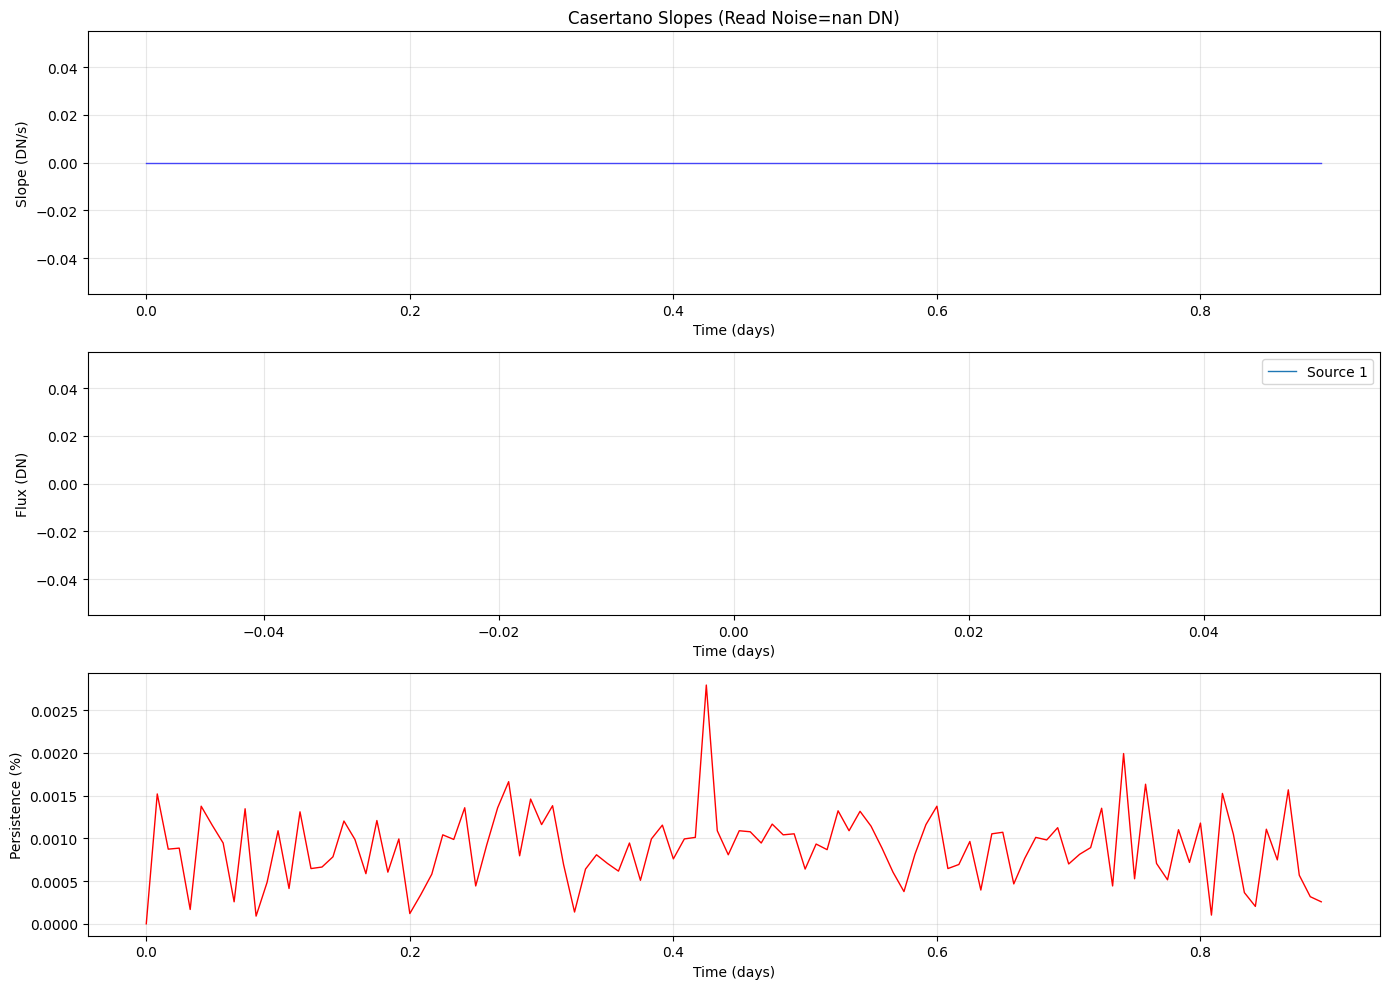

In [22]:
# Plot results
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(l1_df['timestamp_days'], l1_df['mean_slope'], 'b-', alpha=0.7, linewidth=1)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Slope (DN/s)')
axes[0].set_title(f'Casertano Slopes (Read Noise={l1_df["read_noise_used"].iloc[0]:.1f} DN)')
axes[0].grid(True, alpha=0.3)
for sid in phot_df['id'].unique():
    sdata = phot_df[phot_df['id'] == sid]
    axes[1].plot(sdata['image_id']/120, sdata['sum'], label=f'Source {sid}', linewidth=1)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Flux (DN)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(pers_df['timestamp_days'], pers_df['persistence_fraction']*100, 'r-', linewidth=1)
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('Persistence (%)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'./{MAGNITUDE_FOLDER}/analysis_results/summary_plots_{MAG}.png', dpi=150)
plt.show()

## Step 7: Uncertainty Summary

In [23]:
def create_uncertainty_summary(photometry_csv, mag):
    """Create uncertainty summary by image step."""
    
    # Load photometry data
    phot_df = pd.read_csv(photometry_csv)
    
    # Group by image_id and calculate statistics
    summary = phot_df.groupby('image_id').agg({
        'id': 'count',
        'flux_jy_err': ['mean', 'std', 'median'],
        'magnitude_err': ['mean', 'std', 'median'],
        'snr': ['mean', 'std', 'median']
    }).reset_index()
    
    # Flatten column names
    summary.columns = [
        'image_id', 
        'n_stars',
        'flux_err_mean', 'flux_err_std', 'flux_err_median',
        'mag_err_mean', 'mag_err_std', 'mag_err_median',
        'snr_mean', 'snr_std', 'snr_median'
    ]
    
    # Save
    output_csv = os.path.join(RESULTS_DIR, f'Uncertainty_Summary_by_Steps_Mag_{mag}.csv')
    summary.to_csv(output_csv, index=False)
    print(f"\n Created uncertainty summary: {output_csv}")
    
    return summary

# Create uncertainty summary
print(f"\nCreating uncertainty summary...")
create_uncertainty_summary(PHOTOMETRY_CSV, MAG)



Creating uncertainty summary...

 Created uncertainty summary: ./star_mag_20.00/analysis_results/Uncertainty_Summary_by_Steps_Mag_20.csv


,image_id,n_stars,flux_err_mean,flux_err_std,flux_err_median,mag_err_mean,mag_err_std,mag_err_median,snr_mean,snr_std,snr_median
0,1,1,3.369567e-20,NaN,3.369567e-20,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,3.368870e-20,NaN,3.368870e-20,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,3.369775e-20,NaN,3.369775e-20,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,3.367204e-20,NaN,3.367204e-20,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,3.368751e-20,NaN,3.368751e-20,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
103,104,1,3.368445e-20,NaN,3.368445e-20,NaN,NaN,NaN,NaN,NaN,NaN
104,105,1,3.367803e-20,NaN,3.367803e-20,NaN,NaN,NaN,NaN,NaN,NaN
105,106,1,3.370137e-20,NaN,3.370137e-20,NaN,NaN,NaN,NaN,NaN,NaN
106,107,1,3.368587e-20,NaN,3.368587e-20,NaN,NaN,NaN,NaN,NaN,NaN


Loading photometry data from ./star_mag_20.00/analysis_results/Photometry_Mag_20.00.csv...
  Loaded 108 measurements from 108 images

Summary statistics by image:
     image_id  n_stars  flux_err_mean  flux_err_std  flux_err_median  \
0           1        1            0.0           NaN              0.0   
1           2        1            0.0           NaN              0.0   
2           3        1            0.0           NaN              0.0   
3           4        1            0.0           NaN              0.0   
4           5        1            0.0           NaN              0.0   
..        ...      ...            ...           ...              ...   
103       104        1            0.0           NaN              0.0   
104       105        1            0.0           NaN              0.0   
105       106        1            0.0           NaN              0.0   
106       107        1            0.0           NaN              0.0   
107       108        1            0.0        

/tmp/ipykernel_541/1945051345.py:89: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  ax1.errorbar(summary_df['image_id'], summary_df['flux_err_mean'],
/tmp/ipykernel_541/1945051345.py:92: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bs--" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(summary_df['image_id'], summary_df['flux_err_median'], 'bs--',
/tmp/ipykernel_541/1945051345.py:104: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.errorbar(summary_df['image_id'], summary_df['mag_err_mean'],
/tmp/ipykernel_541/1945051345.py:107: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs--" (-> color='r'). The keyword argument will take precedence.
  ax2.p


Side-by-side uncertainty plot saved as: ./star_mag_20.00/analysis_results/Uncertainty_SideBySide_Mag_20.png


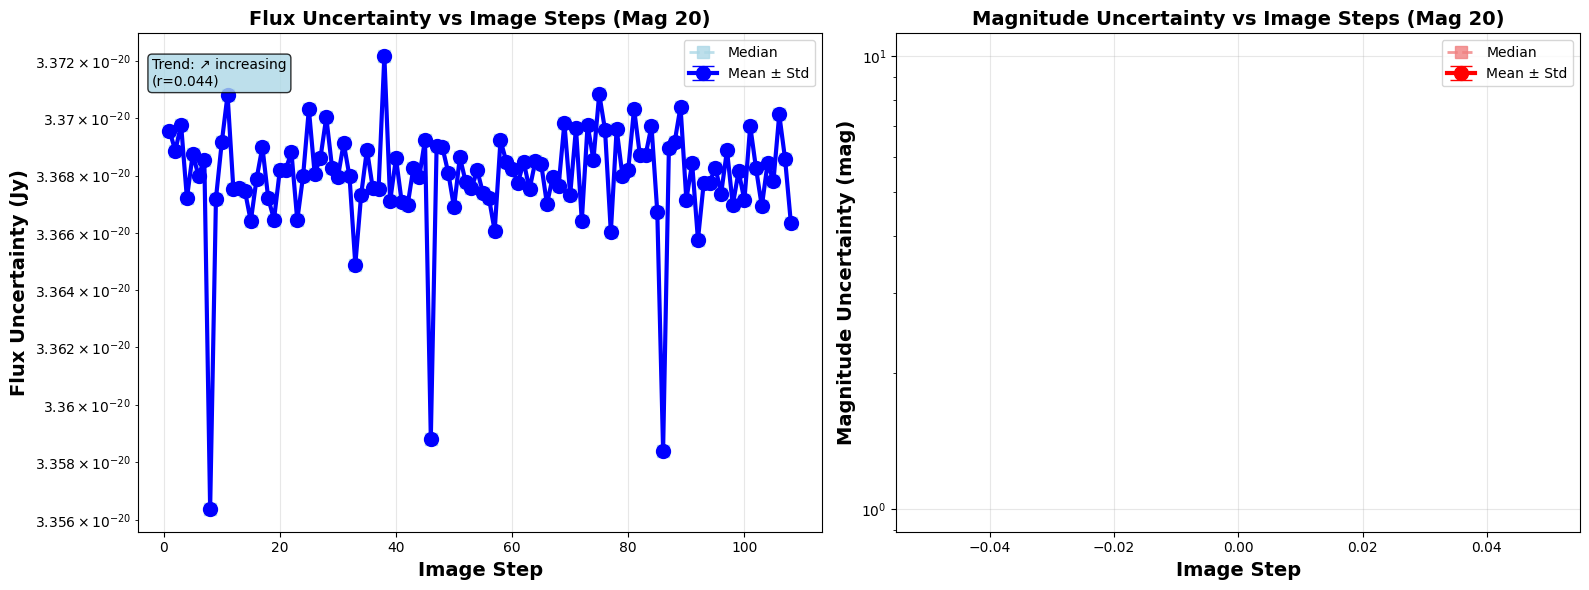


TREND ANALYSIS:
Flux uncertainty trend:
   Slope: 2.91e-26 Jy/step
   R-correlation: 0.044
   P-value: 0.654
   Overall trend: increasing

Summary statistics saved as: ./star_mag_20.00/analysis_results/Uncertainty_Summary_by_Steps_Mag_20.csv


In [24]:
summary_df = plot_uncertainty_by_steps(
    f'./{MAGNITUDE_FOLDER}/analysis_results/Photometry_Mag_{MAG:.2f}.csv',
    mag=MAG,
    plot_style='side_by_side',
    output_dir=f'./{MAGNITUDE_FOLDER}/analysis_results'
)


#### Persistence Summary

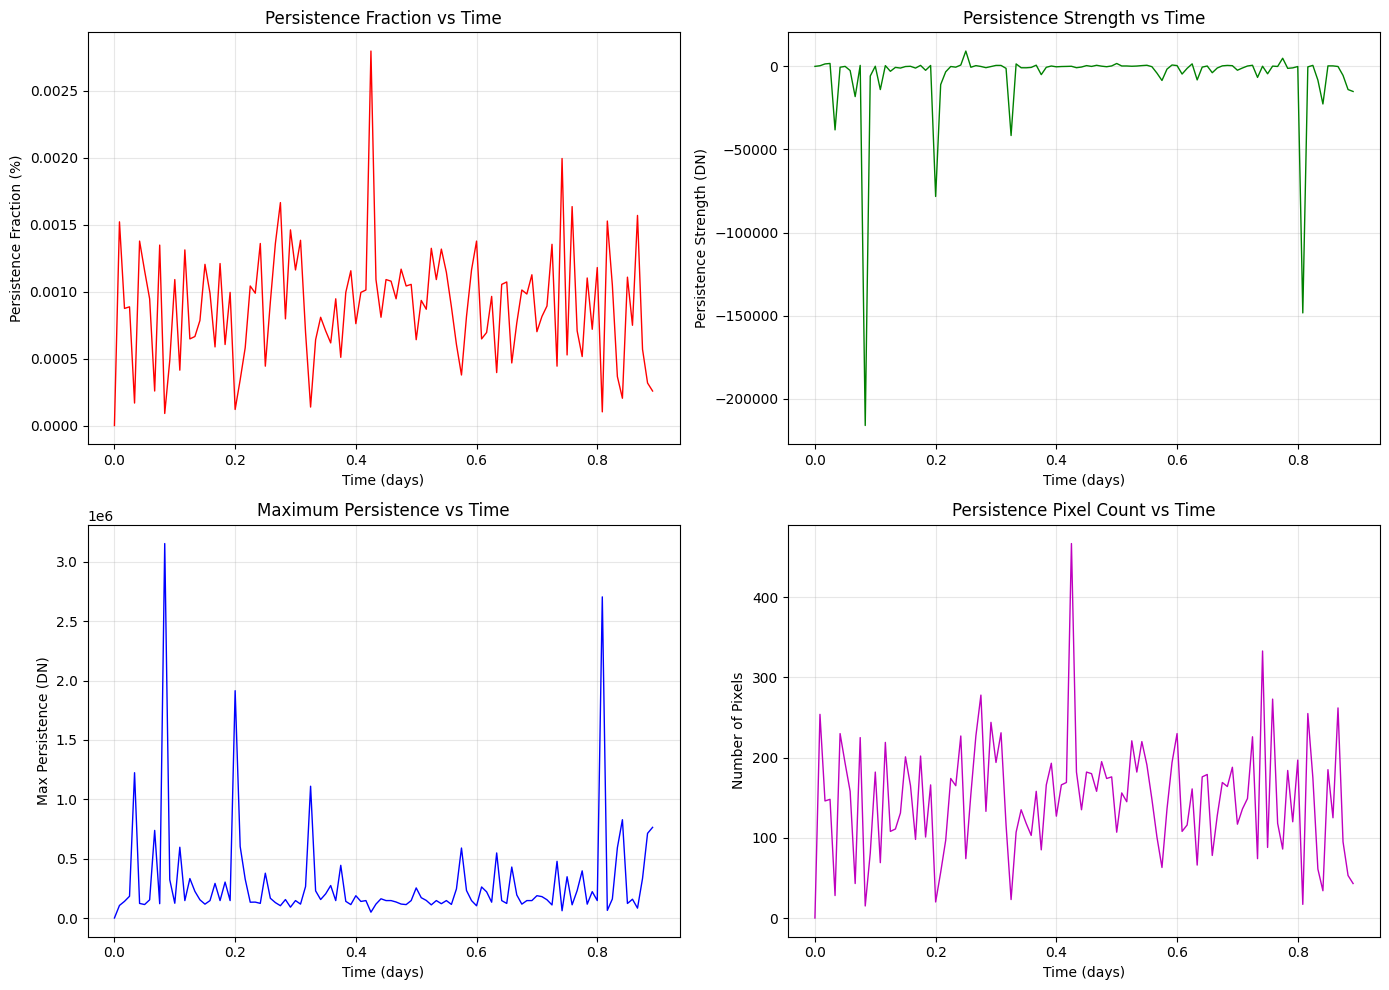

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(pers_df['timestamp_days'], pers_df['persistence_fraction']*100, 'r-', linewidth=1)
axes[0,0].set_xlabel('Time (days)')
axes[0,0].set_ylabel('Persistence Fraction (%)')
axes[0,0].set_title('Persistence Fraction vs Time')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(pers_df['timestamp_days'], pers_df['persistence_strength'], 'g-', linewidth=1)
axes[0,1].set_xlabel('Time (days)')
axes[0,1].set_ylabel('Persistence Strength (DN)')
axes[0,1].set_title('Persistence Strength vs Time')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(pers_df['timestamp_days'], pers_df['persistence_max'], 'b-', linewidth=1)
axes[1,0].set_xlabel('Time (days)')
axes[1,0].set_ylabel('Max Persistence (DN)')
axes[1,0].set_title('Maximum Persistence vs Time')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(pers_df['timestamp_days'], pers_df['n_persistence_pixels'], 'm-', linewidth=1)
axes[1,1].set_xlabel('Time (days)')
axes[1,1].set_ylabel('Number of Pixels')
axes[1,1].set_title('Persistence Pixel Count vs Time')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'./{MAGNITUDE_FOLDER}/analysis_results/persistence_detailed_MAG_{MAG}.png', dpi=150)
plt.show()

NameError: name 'max_val' is not defined

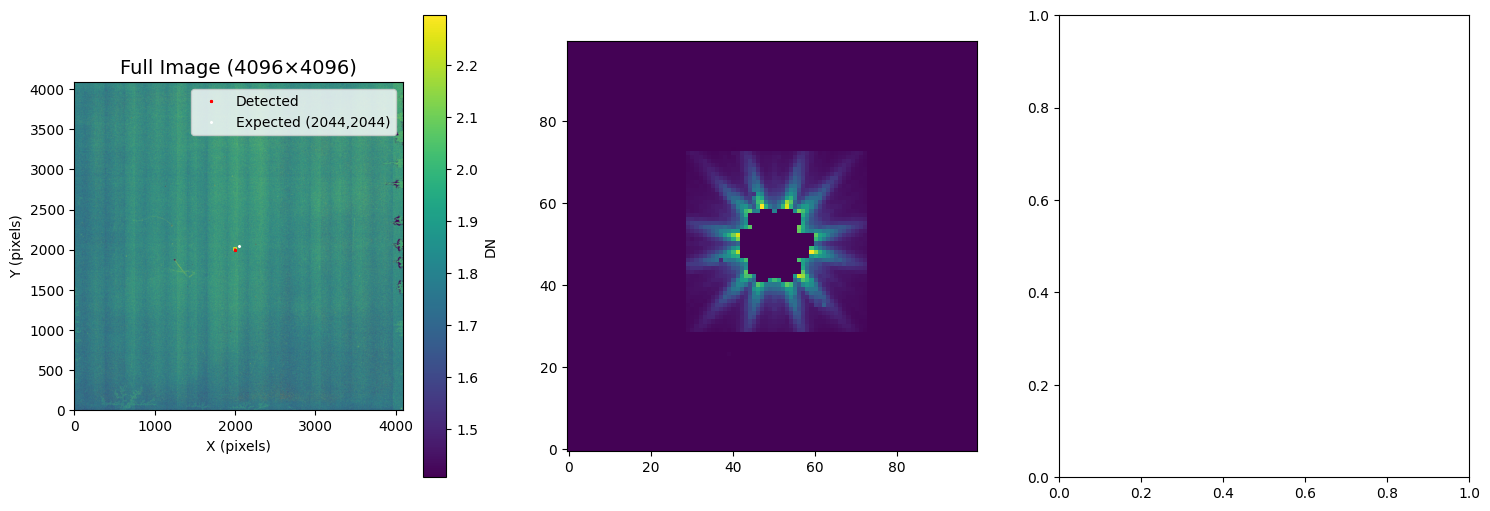

In [26]:
# Create visualization
l2_filename = 'roman_sim_F146_WFI01_L2_1.asdf'
l2_filepath = os.path.join(TEMP_L1_DIR, l2_filename)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

with asdf.open(f'./{MAGNITUDE_FOLDER}/temp_l1_processing/{l2_filename}') as af:
    data = af['roman']['data']
    
    # Full image
    im0 = axes[0].imshow(data, cmap='viridis', origin='lower',
                         vmin=np.nanpercentile(data, 1),
                         vmax=np.nanpercentile(data, 99))
    axes[0].plot(source_x, source_y, 'r*', markersize=2, label='Detected')
    axes[0].plot(2044, 2044, 'wx', markersize=1, mew=2, label='Expected (2044,2044)')
    axes[0].set_title('Full Image (4096×4096)', fontsize=14)
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    axes[0].legend()
    plt.colorbar(im0, ax=axes[0], label='DN')
    
    # 100×100 cutout around detected source
    cutout_size = 50
    y_c = slice(max(0, source_y-cutout_size), min(data.shape[0], source_y+cutout_size))
    x_c = slice(max(0, source_x-cutout_size), min(data.shape[1], source_x+cutout_size))
    cutout = data[y_c, x_c]
    
    im1 = axes[1].imshow(cutout, cmap='viridis', origin='lower')
    axes[1].set_title(f'100×100 Cutout\nPeak: {max_val:.1f} DN', fontsize=14)
    axes[1].set_xlabel('X (pixels)')
    axes[1].set_ylabel('Y (pixels)')
    plt.colorbar(im1, ax=axes[1], label='DN')
    
    # Radial profile
    y_grid, x_grid = np.ogrid[:cutout.shape[0], :cutout.shape[1]]
    r = np.sqrt((x_grid - cutout_size)**2 + (y_grid - cutout_size)**2)
    r_flat = r.flatten()
    cutout_flat = cutout.flatten()
    
    r_bins = np.arange(0, cutout_size, 1)
    radial_profile = []
    for i in range(len(r_bins)-1):
        mask = (r_flat >= r_bins[i]) & (r_flat < r_bins[i+1])
        if mask.sum() > 0:
            radial_profile.append(np.nanmean(cutout_flat[mask]))
        else:
            radial_profile.append(np.nan)
    
    axes[2].plot(r_bins[:-1], radial_profile, 'bo-', linewidth=2)
    axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Radius (pixels)', fontsize=12)
    axes[2].set_ylabel('Mean DN', fontsize=12)
    axes[2].set_title('Radial Profile', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Single Pixel Resultant 1 Variance Plot


ENSEMBLE MAGNITUDE - SATURATED VS UNSATURATED COMPARISON
 Only unsaturated CSV found - plotting single dataset

Unsaturated:
  Found 3721 ensemble pixels
  Valid measurements: 108
  Mean magnitude: 38.3213 mag
  Std deviation: 0.0004 mag
  Variance: 0.000000 mag²


/tmp/ipykernel_541/1323765915.py:84: RuntimeWarning: divide by zero encountered in log10
  mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
/opt/conda/envs/roman-cal/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)



 Saved: ./star_mag_20.00/analysis_results/ensemble_magnitude_comparison.png


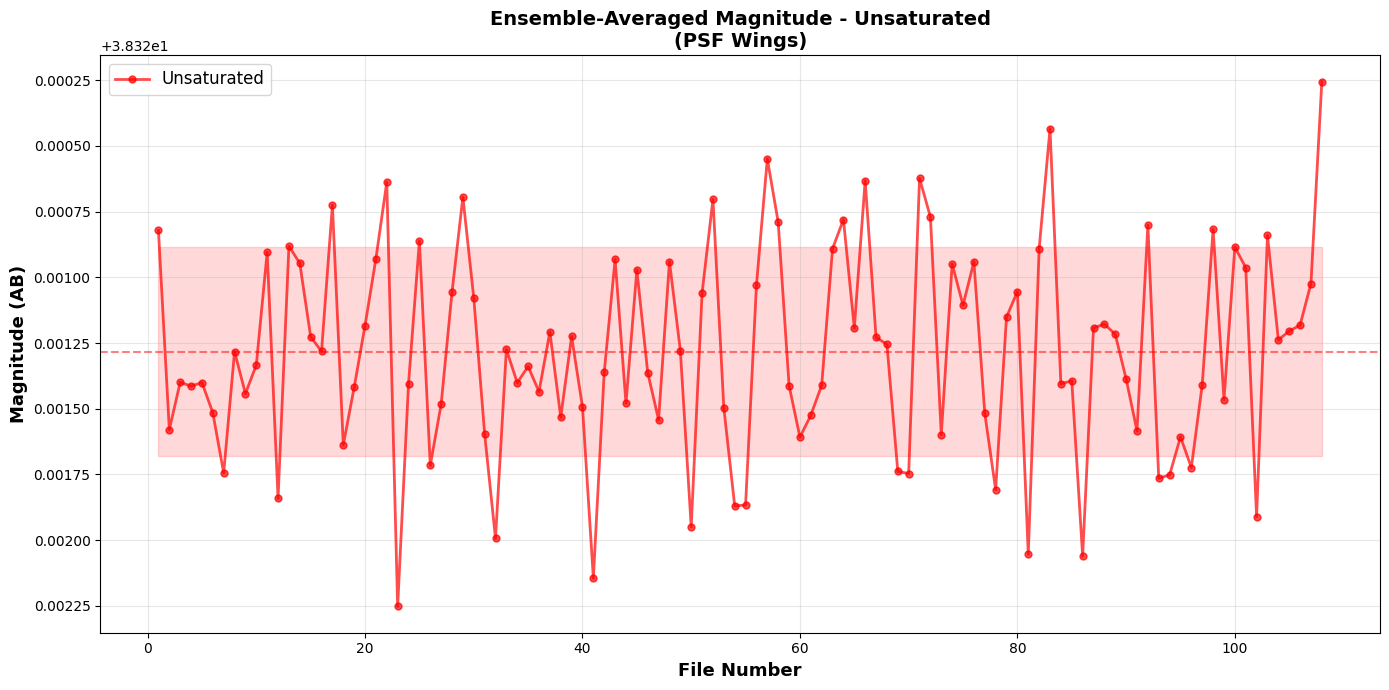

In [27]:
# ============================================================================
# COMPARISON PLOT: Ensemble Magnitude (Saturated vs Unsaturated)
# ============================================================================
print(f"\n{'='*80}")
print("ENSEMBLE MAGNITUDE - SATURATED VS UNSATURATED COMPARISON")
print(f"{'='*80}")

# Configuration
csv_unsat = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_unsat.csv')
csv_sat = os.path.join(RESULTS_DIR, 'multi_pixel_resultant1_sat.csv')

# Check which files exist
has_unsat = os.path.exists(csv_unsat)
has_sat = os.path.exists(csv_sat)

if not has_unsat and not has_sat:
    print(" No CSV files found!")
    print(f"   Expected: {csv_unsat}")
    print(f"         or: {csv_sat}")
else:
    # Determine which files to load
    if has_unsat and not has_sat:
        print(" Only unsaturated CSV found - plotting single dataset")
        csv_files = {'Unsaturated': csv_unsat}
        colors = {'Unsaturated': 'red'}
    elif has_sat and not has_unsat:
        print(" Only saturated CSV found - plotting single dataset")
        csv_files = {'Saturated': csv_sat}
        colors = {'Saturated': 'blue'}
    else:
        print(" Both CSV files found - plotting comparison")
        csv_files = {'Saturated': csv_sat, 'Unsaturated': csv_unsat}
        colors = {'Saturated': 'blue', 'Unsaturated': 'red'}


    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))

    all_stats = {}

    for label, csv_file in csv_files.items():
        df = pd.read_csv(csv_file)
        
        # Filter for ensemble pixels (psf_wing_*)
        df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')]
        
        if len(df_ensemble) == 0:
            print(f" No ensemble pixels in {label} CSV")
            print(f"   Looking for pixels starting with 'psf_wing_'")
            print(f"   Found pixel names: {df['pixel_name'].unique()[:5]}")
            continue
        
        print(f"\n{label}:")
        print(f"  Found {len(df_ensemble['pixel_name'].unique())} ensemble pixels")
        
        # Compute ensemble average for each file
        file_numbers = sorted(df_ensemble['file_number'].unique())
        ensemble_mags = []
        ensemble_stds = []
        
        for file_num in file_numbers:
            df_file = df_ensemble[df_ensemble['file_number'] == file_num]
            dn_values = df_file['resultant_DN'].values
            
            # Filter NaN
            valid_mask = np.isfinite(dn_values)
            dn_valid = dn_values[valid_mask]
            
            if len(dn_valid) == 0:
                continue
            
            # Ensemble average
            mean_dn = np.mean(dn_valid)
            
            # Convert to magnitude
            dn_per_sec = mean_dn / RESULTANT0_TIME
            jy = dn_per_sec * photfnu
            mag = -2.5 * np.log10(jy) + ZERO_POINT_AB
            ensemble_mags.append(mag)
            
            # Std from pixel scatter
            dn_per_sec_all = dn_valid / RESULTANT0_TIME
            jy_all = dn_per_sec_all * photfnu
            mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
            ensemble_stds.append(np.std(mag_all))
        
        ensemble_mags = np.array(ensemble_mags)
        ensemble_stds = np.array(ensemble_stds)
        file_numbers = np.array(file_numbers[:len(ensemble_mags)])
        
        print(f"  Valid measurements: {len(ensemble_mags)}")
        
        if len(ensemble_mags) == 0:
            print(f"   All measurements are invalid")
            all_stats[label] = None
            continue
        
        # Statistics
        mean_mag = np.mean(ensemble_mags)
        std_mag = np.std(ensemble_mags)
        var_mag = np.var(ensemble_mags)
        
        all_stats[label] = {
            'mean': mean_mag,
            'std': std_mag,
            'var': var_mag,
            'n': len(ensemble_mags)
        }
        
        print(f"  Mean magnitude: {mean_mag:.4f} mag")
        print(f"  Std deviation: {std_mag:.4f} mag")
        print(f"  Variance: {var_mag:.6f} mag²")
        
        # Plot
        color = colors[label]
        ax.plot(file_numbers, ensemble_mags, 
               'o-', color=color, linewidth=2, markersize=5, alpha=0.7, label=label)
        
        # Mean line
        ax.axhline(mean_mag, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
        
        # ±1σ band
        ax.fill_between(file_numbers, 
                       mean_mag - std_mag, mean_mag + std_mag,
                       alpha=0.15, color=color)

    # Formatting
    ax.set_xlabel('File Number', fontsize=13, fontweight='bold')
    ax.set_ylabel('Magnitude (AB)', fontsize=13, fontweight='bold')

    if len(csv_files) == 2:
        title = 'Ensemble-Averaged Magnitude Comparison\nSaturated vs Unsaturated (PSF Wings)'
    else:
        mode = list(csv_files.keys())[0]
        title = f'Ensemble-Averaged Magnitude - {mode}\n(PSF Wings)'

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='best')

    plt.tight_layout()

    # Save
    output_file = os.path.join(RESULTS_DIR, 'ensemble_magnitude_comparison.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n Saved: {output_file}")

    plt.show()

    # Print comparison statistics
    if len(all_stats) == 2 and all(v is not None for v in all_stats.values()):
        print("\n" + "="*80)
        print("COMPARISON STATISTICS")
        print("="*80)
        
        sat_stats = all_stats.get('Saturated')
        unsat_stats = all_stats.get('Unsaturated')
        
        if sat_stats and unsat_stats:
            print(f"\n{'Metric':<20} {'Saturated':<20} {'Unsaturated':<20} {'Difference':<15}")
            print("-"*80)
            
            mean_diff = unsat_stats['mean'] - sat_stats['mean']
            var_diff = unsat_stats['var'] - sat_stats['var']
            std_diff = unsat_stats['std'] - sat_stats['std']
            
            print(f"{'Mean (mag)':<20} {sat_stats['mean']:<20.4f} {unsat_stats['mean']:<20.4f} {mean_diff:+.4f}")
            print(f"{'Std Dev (mag)':<20} {sat_stats['std']:<20.4f} {unsat_stats['std']:<20.4f} {std_diff:+.4f}")
            print(f"{'Variance (mag²)':<20} {sat_stats['var']:<20.6f} {unsat_stats['var']:<20.6f} {var_diff:+.6f}")
            print(f"{'N measurements':<20} {sat_stats['n']:<20d} {unsat_stats['n']:<20d} {unsat_stats['n']-sat_stats['n']:+d}")
            
            print("="*80)
            
            # Interpretation
            print("\n" + "="*80)
            print("INTERPRETATION")
            print("="*80)
            
            if abs(mean_diff) < 0.01:
                print(f"\n Means are virtually IDENTICAL ({abs(mean_diff):.4f} mag difference)")
                print("    Saturation removal does not affect ensemble mean brightness")
                print("    PSF wing pixels unaffected by saturation")
            else:
                print(f"\n Means differ by {abs(mean_diff):.3f} mag")
                if mean_diff > 0:
                    print("    Unsaturated is FAINTER")
                else:
                    print("    Saturated is FAINTER")
            
            if abs(var_diff) < 0.001:
                print(f"\n Variances are virtually IDENTICAL ({abs(var_diff):.6f} mag² difference)")
                print("    Saturation removal does not affect variance")
                print("    Ensemble tracking successfully avoids saturated regions")
            else:
                var_pct = (var_diff / sat_stats['var']) * 100
                print(f"\n Variance changed by {var_pct:+.1f}%")
                if var_diff > 0:
                    print("    Unsaturated shows MORE variance")
                else:
                    print("    Saturated shows MORE variance")

print(f"\n{'='*80}")


In [28]:
# ============================================================================
# SIMPLE VIEW: Individual Pixel Magnitude Plots
# ============================================================================
print(f"\n{'='*80}")
print("INDIVIDUAL PIXEL MAGNITUDE PLOTS")
print(f"{'='*80}")

# Load the data
if not os.path.exists(MULTI_PIXEL_CSV):
    print(f" CSV file not found: {MULTI_PIXEL_CSV}")
else:
# Setup correct timing for this resultant
    resultant_num = 0  # Using resultant 0
    resultant_time = RESULTANT_TIMES[resultant_num]  # MA table 1002 timing
    print(f"Using resultant {resultant_num} with timing {resultant_time:.3f}s")

    df = pd.read_csv(MULTI_PIXEL_CSV_FILES[0])
    
    pixel_names = df['pixel_name'].unique()
    print(f" Loaded data for {len(pixel_names)} pixels")
    
    # Select which pixels to plot (skip background for cleaner view)
    pixels_to_plot = ['star_core', 'near_core', 'psf_wing']
    colors = {'star_core': 'red', 'near_core': 'orange', 'psf_wing': 'blue'}
    
    # Filter for available pixels
    available_pixels = [p for p in pixels_to_plot if p in pixel_names]
    
    if len(available_pixels) == 0:
        print(" No pixel data found")
    else:
        # Create figure with 3 subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Individual Pixel Magnitude Time Series\nResultant 1 (3.16 sec)',
                     fontsize=15, fontweight='bold', y=1.02)
        
        for idx, pixel_name in enumerate(available_pixels):
            df_pixel = df[df['pixel_name'] == pixel_name]
            
            if len(df_pixel) == 0:
                continue
            
            file_numbers = df_pixel['file_number'].values
            dn_values = df_pixel['resultant_DN'].values
            distance = df_pixel['distance_from_star'].iloc[0]
            
            # Convert to magnitude
            dn_per_sec = dn_values / RESULTANT0_TIME
            jy_values = dn_per_sec * photfnu
            
            with np.errstate(divide='ignore', invalid='ignore'):
                mag_values = -2.5 * np.log10(jy_values) + ZERO_POINT_AB
            
            # Filter finite values
            finite_mask = np.isfinite(mag_values)
            
            if not np.any(finite_mask):
                print(f" {pixel_name}: All NaN (saturated)")
                continue
            
            # Calculate statistics
            mean_mag = np.mean(mag_values[finite_mask])
            std_mag = np.std(mag_values[finite_mask])
            
            # Plot
            ax = axes[idx]
            color = colors.get(pixel_name)
            
            ax.plot(file_numbers[finite_mask], mag_values[finite_mask], 
                   'o-', color=color, linewidth=1.5, markersize=3, alpha=0.7)
            
            # Mean line
            ax.axhline(mean_mag, color='black', linestyle='--', linewidth=1.5,
                      label=f"Mean = {mean_mag:.2f} mag")
            
            # ±1σ band
            ax.fill_between(file_numbers[finite_mask], 
                           mean_mag - std_mag, mean_mag + std_mag,
                           alpha=0.2, color=color)
            
            ax.set_xlabel('File Number', fontsize=11, fontweight='bold')
            ax.set_ylabel('Magnitude (AB)', fontsize=11, fontweight='bold')
            ax.set_title(f"{pixel_name}", fontsize=12, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            
            print(f"  {pixel_name}: Mean = {mean_mag:.4f} mag, Std = {std_mag:.4f} mag")
        
        plt.tight_layout()
        
        # Save
        output_file = os.path.join(RESULTS_DIR, 'individual_pixel_magnitudes_simple.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n Saved: {output_file}")
        
        plt.show()

print(f"{'='*80}")


INDIVIDUAL PIXEL MAGNITUDE PLOTS
Using resultant 0 with timing 3.162s
 Loaded data for 3721 pixels
 No pixel data found


#### Delta Mag Comparisons

PIXEL-BY-PIXEL PERSISTENCE ANALYSIS

Loading: ./star_mag_20.00/analysis_results/multi_pixel_resultant1_unsat.csv

Analyzing 3721 pixels across 108 exposures


/tmp/ipykernel_541/2416607616.py:50: RuntimeWarning: invalid value encountered in subtract
  delta_mag = mag - mean_mag



 Analyzed 3721 pixels
  Mean RMS: 150.7 mmag
  Median RMS: 19.7 mmag
  Range: 2.9 - 841.1 mmag

Finding outlier pixels (2× neighbors, >50 mmag)...

Found 6 outlier pixels

Top 5 outlier pixels:
--------------------------------------------------------------------------------
  psf_wing_001265 | RMS= 128.9 mmag | 17.5× neighbors | (1990, 2015)
  psf_wing_001234 | RMS=  73.4 mmag | 3.2× neighbors | (1990, 1984)
  psf_wing_000927 | RMS= 533.5 mmag | 2.6× neighbors | (1985, 1982)
  psf_wing_002944 | RMS=  56.5 mmag | 2.4× neighbors | (2018, 1986)
  psf_wing_000393 | RMS= 579.2 mmag | 2.1× neighbors | (1976, 1997)

Creating spatial RMS map...
 Saved: ./star_mag_20.00/analysis_results/pixel_rms_map.png


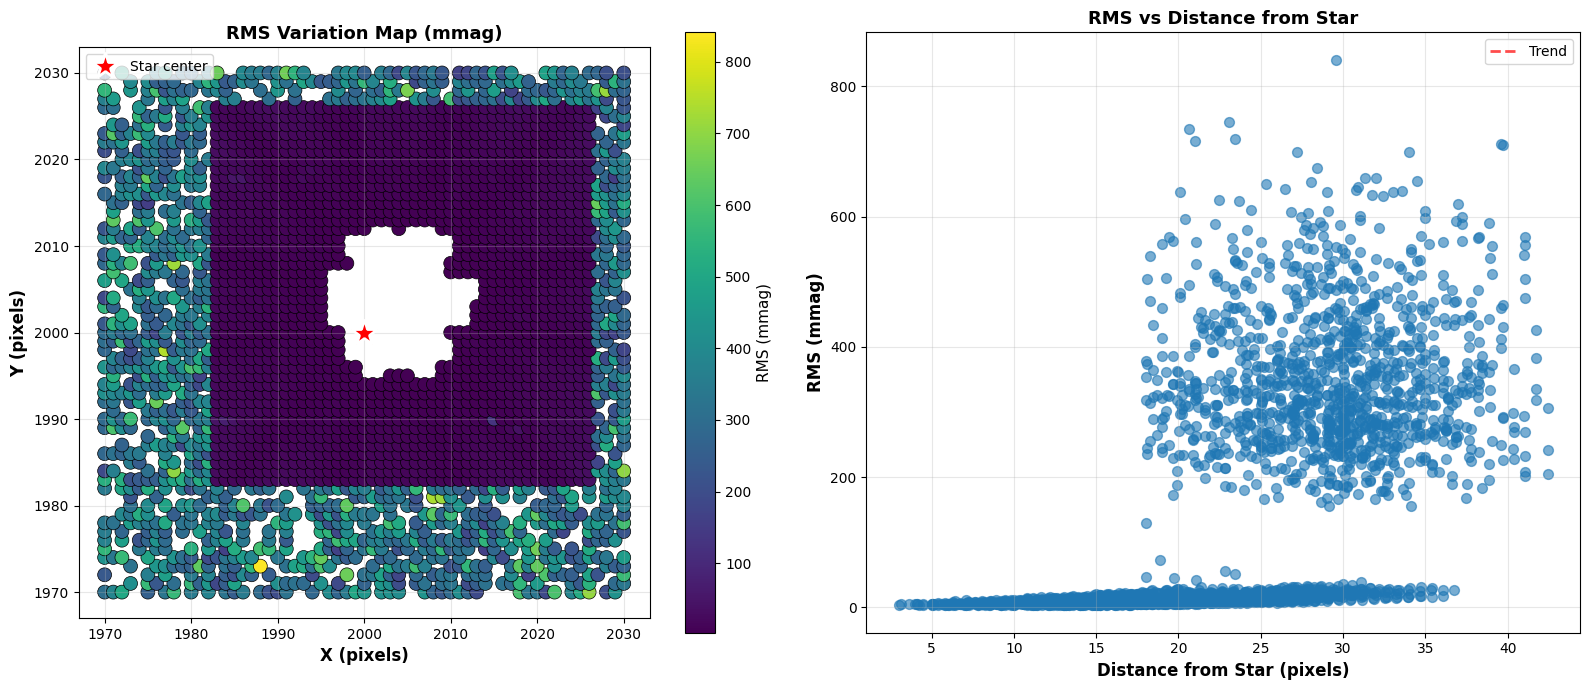


Plotting outlier pixel time series...
 Saved: ./star_mag_20.00/analysis_results/outlier_pixels_timeseries.png


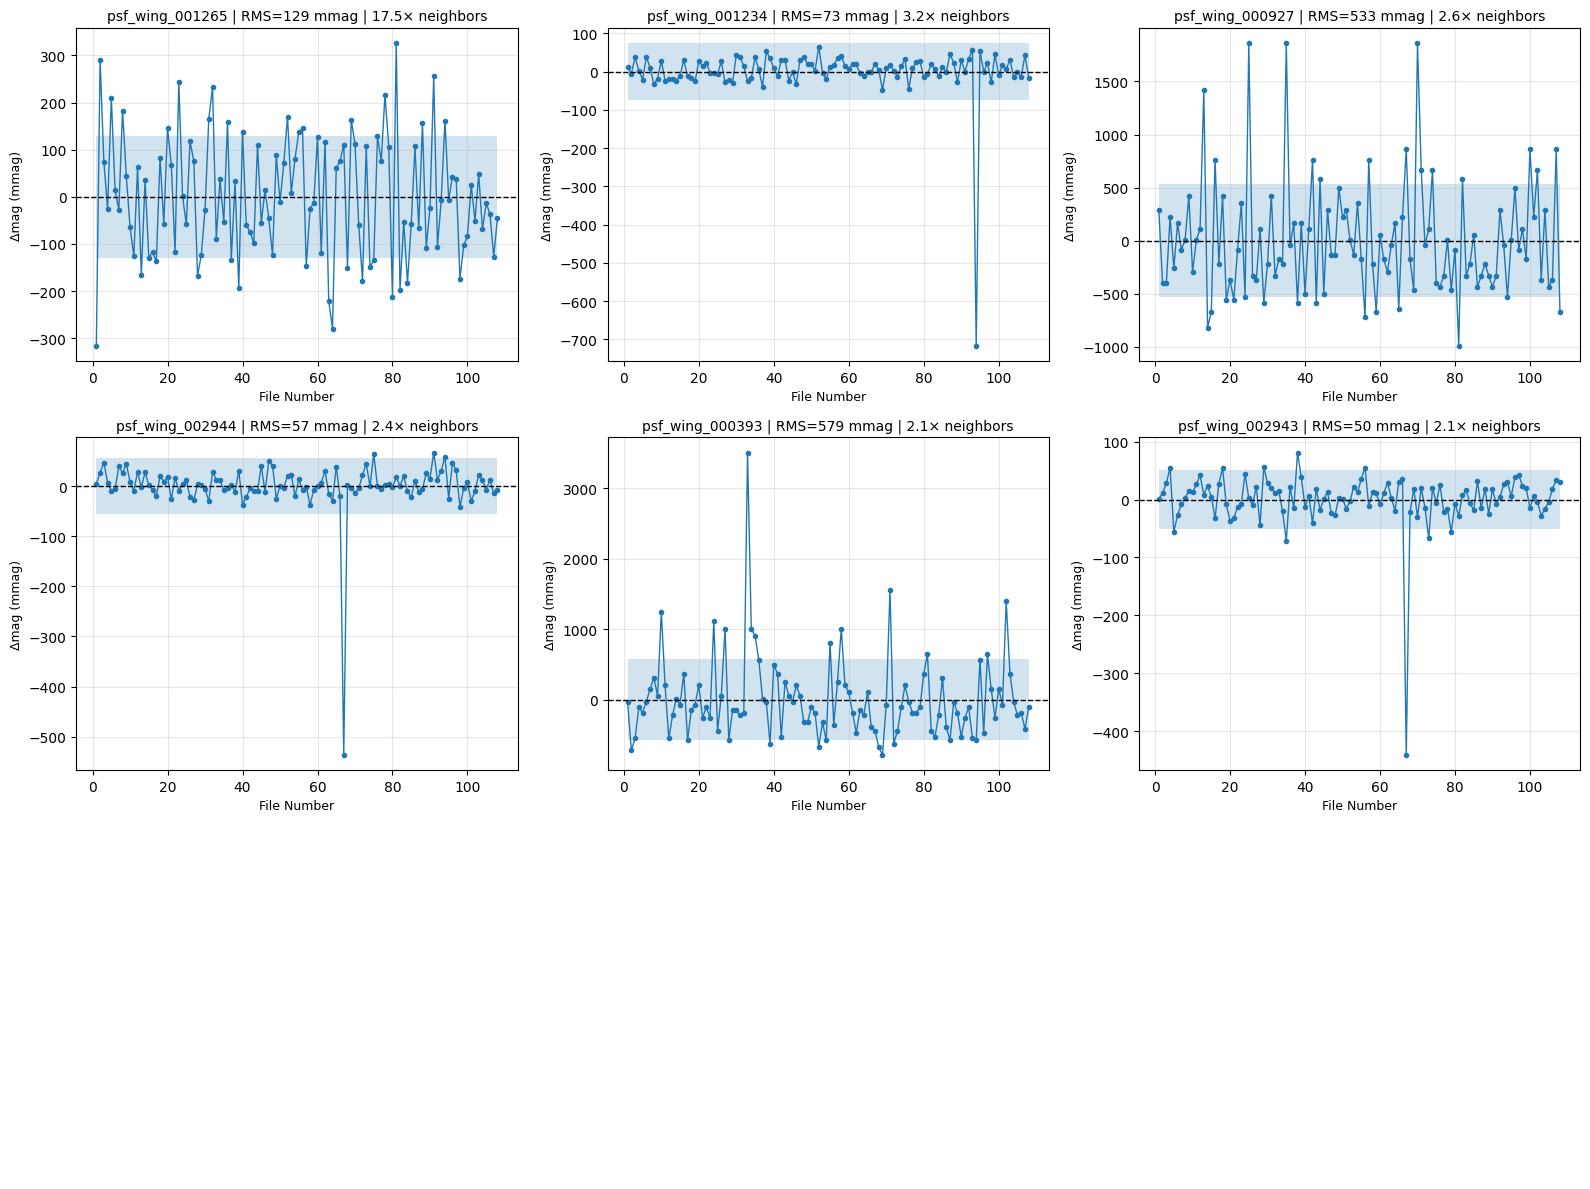


ANALYSIS SUMMARY

Pixels with 50-100 mmag variation: 3 / 3721
  (0.1% of total)

High variation pixels (>100 mmag): 1152
  These may show persistence effects:
    psf_wing_000000 | RMS= 305.4 mmag | r=42.4px
    psf_wing_000001 | RMS= 383.3 mmag | r=41.7px
    psf_wing_000002 | RMS= 504.3 mmag | r=41.0px
    psf_wing_000005 | RMS= 255.5 mmag | r=39.1px
    psf_wing_000007 | RMS= 330.4 mmag | r=37.8px

 Saved results to ./star_mag_20.00/analysis_results/


In [29]:
# ============================================================================
# CELL 23: PIXEL-BY-PIXEL DELTA-MAG ANALYSIS (Professor's Method)
# ============================================================================

print("="*80)
print("PIXEL-BY-PIXEL PERSISTENCE ANALYSIS")
print("="*80)

# Configuration

CSV_FILE = os.path.join(RESULTS_DIR, 
    'multi_pixel_resultant1_unsat.csv' if USE_SATURATION_REMOVAL 
    else 'multi_pixel_resultant1_sat.csv')

# ──────────────────────────────────────────────────────────────────
# FUNCTION: Calculate Δm for each pixel
# ──────────────────────────────────────────────────────────────────

def calculate_pixel_deltamag(csv_file):
    """Calculate Δm for each pixel across all exposures."""
    
    df = pd.read_csv(csv_file)
    pixels = df['pixel_name'].unique()
    
    print(f"\nAnalyzing {len(pixels)} pixels across {len(df['file_number'].unique())} exposures")
    
    results = []
    
    for pixel_name in pixels:
        df_pix = df[df['pixel_name'] == pixel_name]
        
        dn_values = df_pix['resultant_DN'].values
        file_numbers = df_pix['file_number'].values
        
        # Filter NaN
        valid_mask = np.isfinite(dn_values)
        dn_valid = dn_values[valid_mask]
        files_valid = file_numbers[valid_mask]
        
        if len(dn_valid) < 2:
            continue
        
        # Convert to flux and magnitude
        flux = dn_valid / RESULTANT0_TIME * photfnu
        with np.errstate(divide='ignore', invalid='ignore'):
            mag = -2.5 * np.log10(flux) + ZERO_POINT_AB
        
        # Calculate Δm
        mean_mag = np.mean(mag)
        delta_mag = mag - mean_mag
        
        # Statistics
        rms_mmag = np.std(delta_mag) * 1000
        max_deviation = np.max(np.abs(delta_mag)) * 1000
        
        # Get pixel position
        pixel_y = df_pix['pixel_y'].iloc[0]
        pixel_x = df_pix['pixel_x'].iloc[0]
        
        results.append({
            'pixel_name': pixel_name,
            'pixel_y': pixel_y,
            'pixel_x': pixel_x,
            'mean_mag': mean_mag,
            'rms_mmag': rms_mmag,
            'max_deviation_mmag': max_deviation,
            'n_measurements': len(dn_valid),
            'delta_mag': delta_mag,
            'file_numbers': files_valid
        })
    
    return pd.DataFrame(results)


# ──────────────────────────────────────────────────────────────────
# FUNCTION: Find outlier pixels (2× neighbors)
# ──────────────────────────────────────────────────────────────────

def find_outlier_pixels(pixel_stats, threshold_factor=2.0, min_rms=50):
    """Find pixels with variation 2× their spatial neighbors."""
    
    outliers = []
    
    for idx, pixel in pixel_stats.iterrows():
        y, x = pixel['pixel_y'], pixel['pixel_x']
        
        # Find spatial neighbors (±1 pixel)
        neighbors = pixel_stats[
            (np.abs(pixel_stats['pixel_y'] - y) <= 1) &
            (np.abs(pixel_stats['pixel_x'] - x) <= 1) &
            (pixel_stats['pixel_name'] != pixel['pixel_name'])
        ]
        
        if len(neighbors) < 3:
            continue
        
        # Median neighbor RMS
        neighbor_median_rms = np.median(neighbors['rms_mmag'])
        
        # Check if outlier
        ratio = pixel['rms_mmag'] / neighbor_median_rms if neighbor_median_rms > 0 else 0
        
        if ratio > threshold_factor and pixel['rms_mmag'] > min_rms:
            outliers.append({
                'pixel_name': pixel['pixel_name'],
                'pixel_y': y,
                'pixel_x': x,
                'rms_mmag': pixel['rms_mmag'],
                'neighbor_median_rms': neighbor_median_rms,
                'ratio': ratio,
                'n_neighbors': len(neighbors)
            })
    
    return pd.DataFrame(outliers)


# ──────────────────────────────────────────────────────────────────
# RUN ANALYSIS
# ──────────────────────────────────────────────────────────────────

if os.path.exists(CSV_FILE):
    print(f"\nLoading: {CSV_FILE}")
    
    # Step 1: Calculate pixel statistics
    pixel_stats = calculate_pixel_deltamag(CSV_FILE)
    
    print(f"\n Analyzed {len(pixel_stats)} pixels")
    print(f"  Mean RMS: {pixel_stats['rms_mmag'].mean():.1f} mmag")
    print(f"  Median RMS: {pixel_stats['rms_mmag'].median():.1f} mmag")
    print(f"  Range: {pixel_stats['rms_mmag'].min():.1f} - {pixel_stats['rms_mmag'].max():.1f} mmag")
    
    # Step 2: Find outliers
    print("\nFinding outlier pixels (2× neighbors, >50 mmag)...")
    outliers = find_outlier_pixels(pixel_stats, threshold_factor=2.0, min_rms=50)
    
    print(f"\nFound {len(outliers)} outlier pixels")
    
    if len(outliers) > 0:
        print("\nTop 5 outlier pixels:")
        print("-"*80)
        top_outliers = outliers.sort_values('ratio', ascending=False).head()
        for idx, row in top_outliers.iterrows():
            print(f"  {row['pixel_name']:15s} | RMS={row['rms_mmag']:6.1f} mmag | "
                  f"{row['ratio']:.1f}× neighbors | ({row['pixel_y']}, {row['pixel_x']})")
    
    # Step 3: Plot RMS map
    print("\nCreating spatial RMS map...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: RMS map
    y_coords = pixel_stats['pixel_y'].values
    x_coords = pixel_stats['pixel_x'].values
    rms_values = pixel_stats['rms_mmag'].values
    
    scatter1 = ax1.scatter(x_coords, y_coords, c=rms_values, 
                          s=100, cmap='viridis', edgecolors='black', linewidths=0.5)
    ax1.plot(source_x, source_y, '*', color='red', markersize=20, 
            markeredgecolor='white', markeredgewidth=2, label='Star center')
    
    ax1.set_xlabel('X (pixels)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Y (pixels)', fontsize=12, fontweight='bold')
    ax1.set_title('RMS Variation Map (mmag)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('RMS (mmag)', fontsize=11)
    
    # Plot 2: RMS vs distance
    distances = np.sqrt((y_coords - source_y)**2 + (x_coords - source_x)**2)
    
    ax2.scatter(distances, rms_values, alpha=0.6, s=50)
    ax2.set_xlabel('Distance from Star (pixels)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('RMS (mmag)', fontsize=12, fontweight='bold')
    ax2.set_title('RMS vs Distance from Star', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Trend line
    z = np.polyfit(distances, rms_values, 2)
    p = np.poly1d(z)
    x_trend = np.linspace(distances.min(), distances.max(), 100)
    ax2.plot(x_trend, p(x_trend), 'r--', linewidth=2, alpha=0.7, label='Trend')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'pixel_rms_map.png'), dpi=300, bbox_inches='tight')
    print(f" Saved: {RESULTS_DIR}/pixel_rms_map.png")
    plt.show()
    
    # Step 4: Plot outlier time series
    if len(outliers) > 0:
        print("\nPlotting outlier pixel time series...")
        
        n_to_plot = min(9, len(outliers))
        outliers_sorted = outliers.sort_values('ratio', ascending=False)
        
        fig, axes = plt.subplots(3, 3, figsize=(16, 12))
        axes = axes.flatten()
        
        for i in range(n_to_plot):
            ax = axes[i]
            pixel_name = outliers_sorted.iloc[i]['pixel_name']
            
            pixel_data = pixel_stats[pixel_stats['pixel_name'] == pixel_name].iloc[0]
            
            delta_mag = pixel_data['delta_mag']
            files = pixel_data['file_numbers']
            rms = pixel_data['rms_mmag']
            ratio = outliers_sorted.iloc[i]['ratio']
            
            ax.plot(files, delta_mag * 1000, 'o-', linewidth=1, markersize=3)
            ax.axhline(0, color='black', linestyle='--', linewidth=1)
            ax.fill_between(files, -rms, rms, alpha=0.2)
            
            ax.set_xlabel('File Number', fontsize=9)
            ax.set_ylabel('Δmag (mmag)', fontsize=9)
            ax.set_title(f'{pixel_name} | RMS={rms:.0f} mmag | {ratio:.1f}× neighbors', 
                        fontsize=10)
            ax.grid(True, alpha=0.3)
        
        for i in range(n_to_plot, 9):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'outlier_pixels_timeseries.png'), dpi=300, bbox_inches='tight')
        print(f" Saved: {RESULTS_DIR}/outlier_pixels_timeseries.png")
        plt.show()
    
    # Step 5: Summary statistics
    print("\n" + "="*80)
    print("ANALYSIS SUMMARY")
    print("="*80)
    
    target_range = pixel_stats[
        (pixel_stats['rms_mmag'] >= 50) & 
        (pixel_stats['rms_mmag'] <= 100)
    ]
    
    print(f"\nPixels with 50-100 mmag variation: {len(target_range)} / {len(pixel_stats)}")
    print(f"  ({len(target_range)/len(pixel_stats)*100:.1f}% of total)")
    
    high_var = pixel_stats[pixel_stats['rms_mmag'] > 100]
    print(f"\nHigh variation pixels (>100 mmag): {len(high_var)}")
    
    if len(high_var) > 0:
        print("  These may show persistence effects:")
        for idx, row in high_var.head().iterrows():
            dist = np.sqrt((row['pixel_y']-source_y)**2 + (row['pixel_x']-source_x)**2)
            print(f"    {row['pixel_name']:15s} | RMS={row['rms_mmag']:6.1f} mmag | r={dist:.1f}px")
    
    # Save results
    pixel_stats.to_csv(os.path.join(RESULTS_DIR, 'pixel_statistics.csv'), index=False)
    if len(outliers) > 0:
        outliers.to_csv(os.path.join(RESULTS_DIR, 'outlier_pixels.csv'), index=False)
    
    print(f"\n Saved results to {RESULTS_DIR}/")
    print("="*80)
    
else:
    print(f"\n CSV file not found: {CSV_FILE}")
    print("Run Cell 4 first to generate the multi-pixel CSV!")



ENSEMBLE PIXEL ANALYSIS - ALL RESULTANTS - FRACTIONAL VARIATION
 All 5 resultant CSV files found

 Processing Resultant 0 (t = 3.16s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 2.56 mmag, Mean = 38.619 mag

 Processing Resultant 1 (t = 6.32s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 1.89 mmag, Mean = 38.984 mag

 Processing Resultant 2 (t = 12.65s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 0.95 mmag, Mean = 39.473 mag

 Processing Resultant 3 (t = 53.76s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 4.60 mmag, Mean = 40.874 mag

 Processing Resultant 4 (t = 66.41s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 4.76 mmag, Mean = 40.967 mag

 Processing Resultant 5 (t = 69.57s)...
    401868 measurements, 3721 pixels, 108 exposures
    RMS = 5.86 mmag, Mean = 40.952 mag

 Saved: ./star_mag_20.00/analysis_results/ensemble_fractional_variation_all_resultants.png


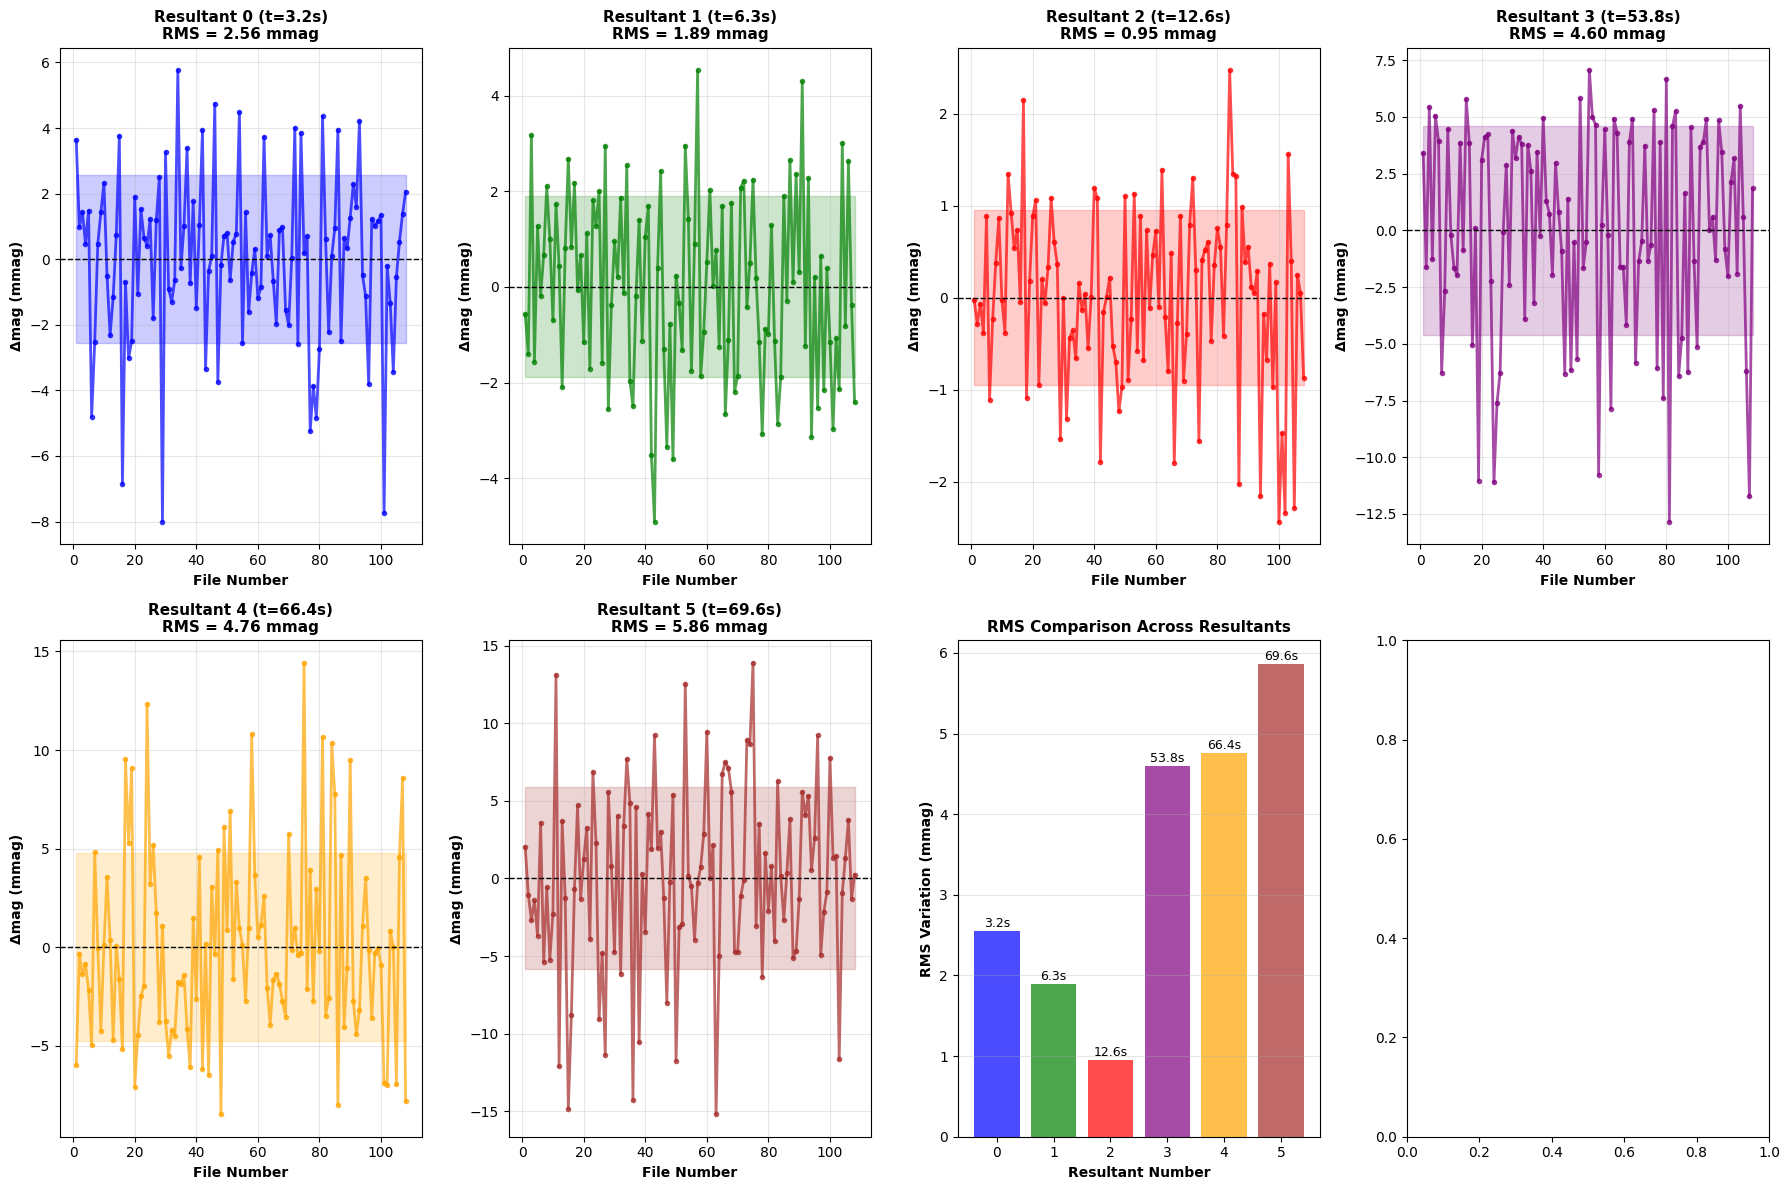

 Saved summary: ./star_mag_20.00/analysis_results/ensemble_analysis_all_resultants_summary.csv

ENSEMBLE ANALYSIS - ALL RESULTANTS SUMMARY
 Resultant  Exposure_Time_s  Mean_Magnitude  RMS_mmag  N_Exposures  Mean_N_Pixels
         0            3.162          38.619     2.556          108       3474.648
         1            6.325          38.984     1.895          108       3426.361
         2           12.650          39.473     0.949          108       3329.944
         3           53.762          40.874     4.601          108       2808.602
         4           66.412          40.967     4.763          108       2563.324
         5           69.574          40.952     5.865          108       2536.306

 BEST PRECISION:
   Resultant 2: 0.95 mmag
   Exposure time: 12.65 seconds
 Saved combined data: ./star_mag_20.00/analysis_results/ensemble_analysis_all_resultants_data.csv


In [30]:
# ============================================================================
# ENSEMBLE PIXEL ANALYSIS - ALL RESULTANTS - Fractional Variation
# ============================================================================

print(f"\n{'='*80}")
print("ENSEMBLE PIXEL ANALYSIS - ALL RESULTANTS - FRACTIONAL VARIATION")
print(f"{'='*80}")

# Check if CSV files exist
missing_files = []
for resultant in range(len(RESULTANT_TIMES)):
    if not os.path.exists(MULTI_PIXEL_CSV_FILES[resultant]):
        missing_files.append(resultant)

if missing_files:
    print(f" Missing CSV files for resultants: {missing_files}")
else:
    print(" All 5 resultant CSV files found")
    
    # Load and process all resultants
    all_resultant_data = {}
    
    for resultant in range(len(RESULTANT_TIMES)):
        print(f"\n Processing Resultant {resultant} (t = {RESULTANT_TIMES[resultant]:.2f}s)...")
        
        # Load data
        df = pd.read_csv(MULTI_PIXEL_CSV_FILES[resultant])
        
        # Filter for PSF wing pixels only
        df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')]
        
        if len(df_ensemble) == 0:
            print(f"    No ensemble pixels found for resultant {resultant}")
            continue
            
        file_numbers = sorted(df_ensemble['file_number'].unique())
        pixels = df_ensemble['pixel_name'].unique()
        
        print(f"    {len(df_ensemble)} measurements, {len(pixels)} pixels, {len(file_numbers)} exposures")
        
        # Compute ensemble average for each file
        ensemble_results = []
        resultant_time = RESULTANT_TIMES[resultant]
        
        for file_num in file_numbers:
            df_file = df_ensemble[df_ensemble['file_number'] == file_num]
            
            # Get DN values
            dn_values = df_file['resultant_DN'].values
            
            # Filter valid values
            valid_mask = np.isfinite(dn_values) & (dn_values > 0)
            dn_valid = dn_values[valid_mask]
            
            if len(dn_valid) == 0:
                continue
            
            # Ensemble average
            mean_dn = np.mean(dn_valid)
            std_dn = np.std(dn_valid)
            
            # Convert to magnitude using correct exposure time
            dn_per_sec = mean_dn / resultant_time
            jy = dn_per_sec * photfnu
            mag = -2.5 * np.log10(jy) + ZERO_POINT_AB
            
            # Magnitude std from pixel scatter
            dn_per_sec_all = dn_valid / resultant_time
            jy_all = dn_per_sec_all * photfnu
            mag_all = -2.5 * np.log10(jy_all) + ZERO_POINT_AB
            std_mag = np.std(mag_all)
            
            ensemble_results.append({
                'file_number': file_num,
                'resultant': resultant,
                'exposure_time': resultant_time,
                'mean_DN': mean_dn,
                'std_DN': std_dn,
                'n_pixels': len(dn_valid),
                'magnitude': mag,
                'mag_std': std_mag
            })
        
        # Convert to DataFrame and store
        df_resultant = pd.DataFrame(ensemble_results)
        
        if len(df_resultant) > 0:
            # Compute fractional variation
            mean_mag = np.mean(df_resultant['magnitude'])
            df_resultant['delta_mag'] = df_resultant['magnitude'] - mean_mag
            rms_variation = np.sqrt(np.mean(df_resultant['delta_mag']**2))
            
            all_resultant_data[resultant] = {
                'data': df_resultant,
                'mean_mag': mean_mag,
                'rms_mmag': rms_variation * 1000,
                'exposure_time': resultant_time
            }
            
            print(f"    RMS = {rms_variation*1000:.2f} mmag, Mean = {mean_mag:.3f} mag")
        else:
            print(f"    No valid data for resultant {resultant}")
    
    if not all_resultant_data:
        print(" No valid data found for any resultant")
    else:
        # Create comprehensive plot
        n_resultants = len(all_resultant_data)
        fig, axes = plt.subplots(2, 4, figsize=(18, 12))
        axes = axes.flatten()
        
        colors = ['blue', 'green', 'red', 'purple', 'orange']
        
        # Plot each resultant
        for i, (resultant, data_dict) in enumerate(all_resultant_data.items()):
            df_data = data_dict['data']
            rms_mmag = data_dict['rms_mmag']
            mean_mag = data_dict['mean_mag']
            exp_time = data_dict['exposure_time']
            
            ax = axes[i]
            file_nums = df_data['file_number'].values
            delta_mag = df_data['delta_mag'].values
            
            # Fractional variation plot
            colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
            
            ax.plot(file_nums, delta_mag * 1000, 'o-', color=colors[i], 
                   linewidth=2, markersize=3, alpha=0.7)
            ax.axhline(0, color='black', linestyle='--', linewidth=1)
            ax.fill_between(file_nums, -rms_mmag, rms_mmag, 
                          alpha=0.2, color=colors[i])
            
            ax.set_xlabel('File Number', fontsize=10, fontweight='bold')
            ax.set_ylabel('Δmag (mmag)', fontsize=10, fontweight='bold')
            ax.set_title(f'Resultant {resultant} (t={exp_time:.1f}s)\n' +
                        f'RMS = {rms_mmag:.2f} mmag',
                        fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        # Summary comparison plot
        if len(all_resultant_data) > 1:
            ax = axes[6]  # Last subplot
            
            resultants = list(all_resultant_data.keys())
            rms_values = [all_resultant_data[r]['rms_mmag'] for r in resultants]
            exp_times = [all_resultant_data[r]['exposure_time'] for r in resultants]
            
            bars = ax.bar(resultants, rms_values, color=[colors[r] for r in resultants], alpha=0.7)
            ax.set_xlabel('Resultant Number', fontsize=10, fontweight='bold')
            ax.set_ylabel('RMS Variation (mmag)', fontsize=10, fontweight='bold')
            ax.set_title('RMS Comparison Across Resultants', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add exposure time labels on bars
            for i, (bar, exp_time) in enumerate(zip(bars, exp_times)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{exp_time:.1f}s', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        
        # Save plot
        output_file = os.path.join(RESULTS_DIR, 'ensemble_fractional_variation_all_resultants.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\n Saved: {output_file}")
        
        plt.show()
        
        # Create summary table
        summary_data = []
        for resultant, data_dict in all_resultant_data.items():
            df_data = data_dict['data']
            summary_data.append({
                'Resultant': resultant,
                'Exposure_Time_s': data_dict['exposure_time'],
                'Mean_Magnitude': data_dict['mean_mag'],
                'RMS_mmag': data_dict['rms_mmag'],
                'N_Exposures': len(df_data),
                'Mean_N_Pixels': np.mean(df_data['n_pixels'])
            })
        
        summary_df = pd.DataFrame(summary_data)
        
        # Save summary table
        summary_file = os.path.join(RESULTS_DIR, 'ensemble_analysis_all_resultants_summary.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f" Saved summary: {summary_file}")
        
        # Print comprehensive statistics
        print("\n" + "="*80)
        print("ENSEMBLE ANALYSIS - ALL RESULTANTS SUMMARY")
        print("="*80)
        print(summary_df.to_string(index=False, float_format='%.3f'))
        print("="*80)
        
        # Find best precision resultant
        best_resultant = summary_df.loc[summary_df['RMS_mmag'].idxmin()]
        print(f"\n BEST PRECISION:")
        print(f"   Resultant {int(best_resultant['Resultant'])}: {best_resultant['RMS_mmag']:.2f} mmag")
        print(f"   Exposure time: {best_resultant['Exposure_Time_s']:.2f} seconds")
        
        # Save combined data for further analysis
        combined_df = pd.concat([data['data'] for data in all_resultant_data.values()], ignore_index=True)
        combined_file = os.path.join(RESULTS_DIR, 'ensemble_analysis_all_resultants_data.csv')
        combined_df.to_csv(combined_file, index=False)
        print(f" Saved combined data: {combined_file}")

print(f"{'='*80}")

#### Step : Flux Matrix Creation

In [31]:
"""
Flux Matrix Creator - ALL RESULTANTS with DISTANCE-ORDERED COLUMNS
Creates flux matrices for all 5 resultants with columns sorted by distance from star
"""
print("="*80)
print("CREATING FLUX MATRICES FOR ALL RESULTANTS - DISTANCE ORDERED COLUMNS")
print("="*80)

start_time = time.time()

def sort_pixels_by_distance_from_star(pixel_names, df_sample, star_y=source_y, star_x=source_x):
    """
    Sort pixel names by their distance from the star center.
    Returns pixel names sorted by distance (closest first).
    """
    print(" Sorting pixels by distance from star...")
    
    # Get pixel positions and calculate distances
    pixel_distances = []
    
    for pixel_name in pixel_names:
        # Get pixel position from the data
        pixel_row = df_sample[df_sample['pixel_name'] == pixel_name].iloc[0]
        y, x = pixel_row['pixel_y'], pixel_row['pixel_x']
        
        # Calculate distance from star
        distance = np.sqrt((y - star_y)**2 + (x - star_x)**2)
        
        pixel_distances.append({
            'name': pixel_name,
            'y': y,
            'x': x,
            'distance': distance
        })
    
    # Sort by distance (closest first)
    pixel_distances.sort(key=lambda p: p['distance'])
    
    # Extract sorted names
    sorted_names = [p['name'] for p in pixel_distances]
    
    print(f"    Sorted {len(sorted_names)} pixels by distance")
    print(f"    Closest: {pixel_distances[0]['name']} at {pixel_distances[0]['distance']:.1f}px")
    print(f"    Farthest: {pixel_distances[-1]['name']} at {pixel_distances[-1]['distance']:.1f}px")
    
    return sorted_names, pixel_distances

def process_resultant_with_distance_ordering(resultant):
    """Process a single resultant with distance-ordered columns."""
    input_csv = MULTI_PIXEL_CSV_FILES[resultant]
    resultant_time = RESULTANT_TIMES[resultant]
    
    print(f"\n Processing Resultant {resultant} (t = {resultant_time:.2f}s)...")
    
    if not os.path.exists(input_csv):
        print(f"    CSV file not found: {input_csv}")
        return None
    
    # Load data
    load_start = time.time()
    df = pd.read_csv(input_csv)
    load_time = time.time() - load_start
    print(f"Loaded {len(df):,} rows in {load_time:.1f}s")
    
    # Filter for PSF wing pixels only
    df_ensemble = df[df['pixel_name'].str.startswith('psf_wing_')].copy()
    
    # Remove duplicates
    n_before = len(df_ensemble)
    df_ensemble = df_ensemble.drop_duplicates(subset=['file_number', 'pixel_name'], keep='first')
    n_after = len(df_ensemble)
    if n_before != n_after:
        print(f"   🔧 Removed {n_before - n_after} duplicate entries")
    
    if len(df_ensemble) == 0:
        print(f"    No ensemble pixels found for resultant {resultant}")
        return None
    
    # Get file numbers and pixel names
    file_numbers = sorted(df_ensemble['file_number'].unique())
    pixel_names_unsorted = df_ensemble['pixel_name'].unique()
    
    print(f"{len(file_numbers)} exposures × {len(pixel_names_unsorted)} pixels")

    # JCZ commented out
    #  CRITICAL: Sort pixels by distance from star (closest first)
    # pixel_names_sorted, pixel_info = sort_pixels_by_distance_from_star(
    #     pixel_names_unsorted, df_ensemble
    # )
    
    # Convert DN to flux - vectorized operation
    conversion_start = time.time()
    df_ensemble['flux_jy'] = np.where(
        (df_ensemble['resultant_DN'].notna()) & (df_ensemble['resultant_DN'] > 0),
        (df_ensemble['resultant_DN'] / resultant_time) * photfnu,
        np.nan
    )
    conversion_time = time.time() - conversion_start
    print(f"    Converted {len(df_ensemble):,} values in {conversion_time:.2f}s")
    df_ensemble['pixel_name_alt'] = ["x{}y{}".format(x,y) for x, y in zip(df_ensemble['pixel_x'], df_ensemble['pixel_y'])]
    print(df_ensemble['pixel_name_alt'])
    # Create matrix using pivot
    pivot_start = time.time()
    flux_df = df_ensemble.pivot(
        index='file_number',
        columns='pixel_name_alt',  # JCZ changed to alt
        values='flux_jy'
    )
    # JCZ commented out
    #  CRITICAL: Reorder columns by distance (closest first)
    #flux_df = flux_df.reindex(columns=pixel_names_sorted)
    
    pivot_time = time.time() - pivot_start
    print(f"Created {flux_df.shape[0]} × {flux_df.shape[1]} matrix in {pivot_time:.2f}s")
    print(f"    Columns ordered by distance (closest to farthest)")
    
    # Reset index to make file_number a column
    flux_df = flux_df.reset_index()
    
    # Verify column ordering
    final_columns = flux_df.columns.tolist()[1:]  # Skip 'file_number'
    print(f"    First 5 columns: {[col[:15] for col in final_columns[:5]]}")
    print(f"    Last 5 columns: {[col[:15] for col in final_columns[-5:]]}")
    
    # Save with distance-ordered columns
    output_file = os.path.join(RESULTS_DIR, f'flux_matrix_resultant{resultant}_MAG_{MAG:.2f}.csv')
    save_start = time.time()
    flux_df.to_csv(output_file, index=False)
    save_time = time.time() - save_start
    print(f"    Saved: {os.path.basename(output_file)} in {save_time:.2f}s")
 
    # Calculate statistics
    flux_matrix = flux_df.drop(columns=['file_number']).values
    n_valid = np.sum(np.isfinite(flux_matrix))
    n_total = flux_matrix.size
    pct_valid = n_valid / n_total * 100
    
    result_stats = {
        'resultant': resultant,
        'exposure_time': resultant_time,
        'shape': flux_matrix.shape,
        'n_valid': n_valid,
        'n_total': n_total,
        'pct_valid': pct_valid,
        'flux_min': np.nanmin(flux_matrix),
        'flux_max': np.nanmax(flux_matrix),
        'flux_median': np.nanmedian(flux_matrix),
        'output_file': output_file,
        'processing_time': time.time() - load_start,
    }
    
    print(f"    {pct_valid:.1f}% valid data")
    
    return result_stats

# Check if all CSV files exist
missing_files = []
for resultant in range(len(RESULTANT_TIMES)):
    if not os.path.exists(MULTI_PIXEL_CSV_FILES[resultant]):
        missing_files.append(resultant)

print(len(PIXELS_TO_TRACK))
if missing_files:
    print(f" Missing CSV files for resultants: {missing_files}")
else:
    print(" All resultant CSV files found")
    
    # Process all resultants with distance ordering
    print(f"\n Processing all resultants with distance-ordered columns...")
    all_results = []
    
    for resultant in range(len(RESULTANT_TIMES)):
        print(resultant)
        result = process_resultant_with_distance_ordering(resultant)
        if result:
            all_results.append(result)
    
    if not all_results:
        print(" No valid results from any resultant")
    else:
        print(f"\n Successfully processed {len(all_results)} resultants")
        
        # Create comprehensive summary
        print("\n" + "="*80)
        print("DISTANCE-ORDERED FLUX MATRIX STATISTICS")
        print("="*80)
        
        summary_rows = []
        for result in all_results:
            summary_rows.append({
                'Resultant': result['resultant'],
                'Exp_Time_s': result['exposure_time'],
                'Shape': f"{result['shape'][0]}×{result['shape'][1]}",
                'Valid_%': f"{result['pct_valid']:.1f}%", 
                'Flux_Range': f"{result['flux_min']:.1e} - {result['flux_max']:.1e} Jy",
                'Time_s': f"{result['processing_time']:.1f}s"
            })
        
        summary_df = pd.DataFrame(summary_rows)
        print(summary_df.to_string(index=False))
        
        # Save summary table
        summary_file = os.path.join(RESULTS_DIR, f'flux_matrix_distance_ordered_summary_MAG_{MAG:.2f}.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f"\n Summary: {summary_file}")
     
        print(f"\n SUCCESS! All flux matrices have distance-ordered columns")
        print(f"\n USAGE EXAMPLES:")
        print(f"   # Load any resultant")
        print(f"   df = pd.read_csv('flux_matrix_distance_ordered_resultant0_MAG_{MAG:.2f}.csv')")
        print(f"   # Get 50 closest pixels: df.iloc[:, 1:51]")
        print(f"   # Get single closest pixel: df.iloc[:, 1]")
        print(f"   # Get background pixels: df.iloc[:, -20:]")
        
        print("="*80)


CREATING FLUX MATRICES FOR ALL RESULTANTS - DISTANCE ORDERED COLUMNS
0
 All resultant CSV files found

 Processing all resultants with distance-ordered columns...
0

 Processing Resultant 0 (t = 3.16s)...
Loaded 401,868 rows in 0.2s
108 exposures × 3721 pixels
    Converted 401,868 values in 0.00s
0         x1970y1970
1         x1971y1970
2         x1972y1970
3         x1973y1970
4         x1974y1970
             ...    
401863    x2026y2030
401864    x2027y2030
401865    x2028y2030
401866    x2029y2030
401867    x2030y2030
Name: pixel_name_alt, Length: 401868, dtype: object
Created 108 × 3721 matrix in 0.05s
    Columns ordered by distance (closest to farthest)
    First 5 columns: ['x1970y1970', 'x1970y1971', 'x1970y1972', 'x1970y1973', 'x1970y1974']
    Last 5 columns: ['x2030y2026', 'x2030y2027', 'x2030y2028', 'x2030y2029', 'x2030y2030']
    Saved: flux_matrix_resultant0_MAG_20.00.csv in 0.72s
    93.4% valid data
1

 Processing Resultant 1 (t = 6.32s)...
Loaded 401,868 rows in 0.2